## Import libraries

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

plt.rcParams["text.usetex"] = True

In [2]:
import warnings
import torch
import torch.nn as nn

# Suppress Intel Iris Xe "not officially supported" warning
warnings.filterwarnings(
    "ignore",
    message=".*detected GPU.*not officially supported by PyTorch XPU.*")

# Define the GPU type ("cuda" for NVIDIA GPUs, "xpu" for Intel GPUs)
gpu_type = "xpu"

if gpu_type == "cuda":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
elif gpu_type == "xpu":
    device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
else:
    raise ValueError("Invalid GPU type. Use 'cuda' or 'xpu'.")

print(f"Using device: {device}")

Using device: xpu


# Numerical Ground Truth

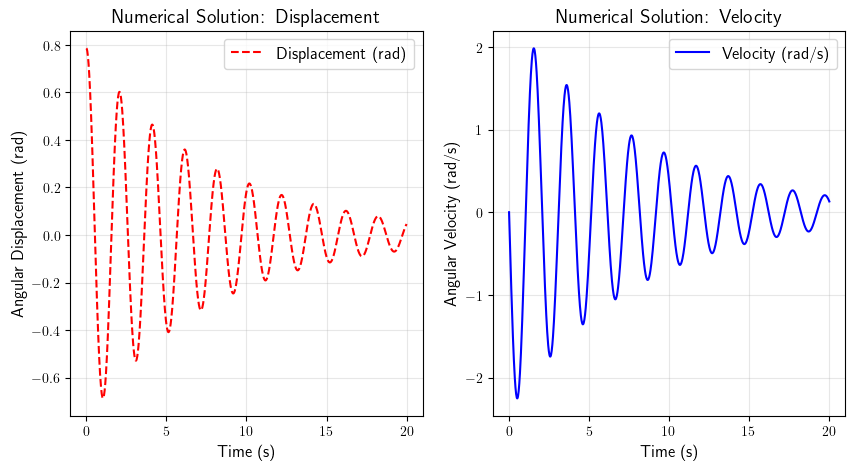

In [3]:
# Physical parameters
g = 9.81
L = 1.0
m = 1.0
b = 0.25

# Initial conditions
# Starting at 45 degrees with zero initial angular velocity
theta0_ground_truth = 45 * np.pi / 180   # 45 degrees in radians
omega0_ground_truth = 0.0

t_start = 0
t_end   = 20
t_range_ode_ground_truth = np.linspace(t_start, t_end, 1000)

# Define the pendulum system as a first-order ODE
def pendulum_system(states, t, g, L, b, m):
    theta, omega = states
    return [omega, -(g / L) * np.sin(theta) - (b / m) * omega]

# Compute the ground truth solution using odeint
solution_ground_truth  = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_range_ode_ground_truth,
    args=(g, L, b, m))

# Extract theta and theta_dot from the solution
theta_ground_truth     = solution_ground_truth[:, 0]
theta_dot_ground_truth = solution_ground_truth[:, 1]

# ----------------------------------------------------------------------------
# Plot the numerical solution
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 5))
fig.subplots_adjust(hspace=0.3)

#  Displacement plot 
axes[0].plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    linestyle='dashed',
    color='red',
    label=r'Displacement (rad)')
axes[0].set_xlabel('Time (s)', fontsize=12)
axes[0].set_ylabel(r'Angular Displacement (rad)', fontsize=12)
axes[0].set_title(r'Numerical Solution: Displacement', fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

#  Velocity plot 
axes[1].plot(
    t_range_ode_ground_truth,
    theta_dot_ground_truth,
    linestyle='solid',
    color='blue',
    label=r'Velocity (rad/s)')
axes[1].set_xlabel(r'Time (s)', fontsize=12)
axes[1].set_ylabel(r'Angular Velocity (rad/s)', fontsize=12)
axes[1].set_title(r'Numerical Solution: Velocity', fontsize=14)
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

# Create "figures" directory if it doesn't exist
os.makedirs("figures", exist_ok=True)

# Save the figure with high resolution
plt.savefig(
    "figures/numerical_solution.png",
    dpi=600,
    bbox_inches='tight')

plt.show()

# Fourier Feature PINN

## Why the baseline PINN struggles at late times

A standard fully connected network with Tanh activations suffers from **spectral bias**, which means it learns low-frequency components of the target function first and converges extremely slowly to higher-frequency details. For the damped pendulum, the oscillation frequency is $\omega_n = \sqrt{g/L} \approx 3.13$ rad/s (period $\approx 2$ s), so the network must represent roughly 10 full cycles across 20 seconds. At late times ($t > 15$ s) the oscillation amplitude has decayed to $\sim$ 0.01 rad (*i.e.,* tiny ripples that the network effectively ignores) because the squared residual they produce is negligible compared to the early-time, large-amplitude signal.

## Fourier feature input embedding: frequency bands

Neural networks with smooth activations such as `Tanh` exhibit spectral bias, which means they tend to converge rapidly on low-frequency modes while underrepresent the higher-frequency oscillations. In our damped pendulum case study, this means that network tends to capture the slow decay oscillations at the beginning, but fails to track the pendulum's rapid oscillations towards the end. To overcome this limitation, we can prepend a fixed Fourier embedding layer that maps each time point $t$ to $\sin(\omega_k t)$ and $\cos(\omega_k t)$ at selected multiples of the natural frequency $\omega_n$. 

The natural frequency can be calculated as follows:

$$
\omega_n = \sqrt{\frac{g}{L}} \approx 3.13\;\text{rad/s} \approx 2 \text{s},
$$

which is the frequency at which the pendulum would oscillate if there were no damping and the angle were small. As the $\sin\theta$ nonlinearity in the ODE generates harmonics beyond the fundamental frequency, we choose five different multipliers of the natural frequency ($0.5\,\omega_n$, $1.0\,\omega_n$, $1.5\,\omega_n$, $2.0\,\omega_n$ and $3.0\,\omega_n$) to create the Fourier features:

| Band | Frequency | Purpose |
|------|-----------|---------|
| $0.5\,\omega_n$ | $\approx 1.57$ rad/s | The damping causes the oscillation amplitude to decay on a timescale slower than one period. This sub-harmonic captures that slow decay. |
| $1.0\,\omega_n$ | $\approx 3.13$ rad/s | The fundamental oscillation frequency $\omega_n = \sqrt{g/L}$. |
| $1.5\,\omega_n$ | $\approx 4.70$ rad/s | Accounts for the nonlinear frequency shift from the natural frequency. |
| $2.0\,\omega_n$ | $\approx 6.27$ rad/s | 2nd harmonic at twice the fundamentals. |
| $3.0\,\omega_n$ | $\approx 9.40$ rad/s | 3rd harmonic for higher-order nonlinear oscillations. |

Each time point $t$ is mapped to $\sin(\omega_k t)$ and $\cos(\omega_k t)$ for each of these five frequencies, which produce 10 Fourier features. Together with the normalised time $\tilde{t}$, the network receives an 11-dimensional input vector instead of a scalar.

The full input vector for each time point is:

$$
\begin{aligned}
\mathbf{x}(t) = \bigl[\,& \tilde{t},\; \underbrace{\sin(0.5\,\omega_n t),\, \cos(0.5\,\omega_n t)}_{\text{decay envelope}},\; \underbrace{\sin(1.0\,\omega_n t),\, \cos(1.0\,\omega_n t)}_{\text{fundamental}},\; 
\\ & \underbrace{\sin(1.5\,\omega_n t),\, \cos(1.5\,\omega_n t)}_{\text{nonlinear shift}},\; \underbrace{\sin(2.0\,\omega_n t),\, \cos(2.0\,\omega_n t)}_{\text{2nd harmonic}},\; \underbrace{\sin(3.0\,\omega_n t),\, \cos(3.0\,\omega_n t)}_{\text{3rd harmonic}}\,\bigr] \in \mathbb{R}^{11}
\end{aligned}
$$

These Fourier features are **frozen** (not trained) as they simply provide the network with the right oscillatory basis functions so that the hidden layers only need to learn amplitudes and phases, not the frequencies themselves.

## Architecture summary

The `FourierFeatureNN` class defined earlier constructs the augmented input internally:

1. **Input embedding** (frozen, not trained): $t \mapsto [\tilde{t},\;\sin(\omega_k t),\;\cos(\omega_k t)]$ (dimension $1 + 2K = 11$)
2. **Hidden layers**: same Tanh MLP as before ($n_\text{layers} \times n_\text{hidden}$), but now operating on the 11-dimensional input
3. **Output**: single normalized displacement $\tilde{\theta}$

Because the sinusoidal features are computed from *physical* time (not normalized time), the network receives physical time as input and handles normalization internally. This means all calls to `pinn()` in the training loop pass raw time values (*i.e.* no more `normalize_time_input()`).

::: {.callout-tip}
## Fourier features vs SIREN

An alternative approach is **SIREN** (Sinusoidal Representation Networks), which replaces Tanh with $\sin(\omega_0 \cdot \text{pre-activation})$ throughout the network. SIREN makes *every* layer oscillatory, whereas Fourier features only augment the *input*. Fourier features are simpler to implement, require no special weight initialization, and work well when the expected frequencies are known (as they are here from the physics). SIREN is more powerful for problems where the frequency content is unknown or spatially varying.
:::

## Advanced Training Configurations for Fourier Feature PINN

Although Fourier features transformation solve the non-linear frequency representation problem so that the network can now express oscillatory functions natively, it is important to note that this representation alone does not guarantee that the optimizer will be able to find the correct ODE solution due to the influence of noisy data. The loss landscape remains difficult as noisy measurements create many shallow local minima, where the physics residual must be satisfied over a 20 s window containing ~10 oscillation cycles with decaying amplitude and deteriorating Signal-to-Noise Ratio (SNR).

To address this optimization problem, we include four training strategies on top of the Fourier feature architecture. Each method targets a different failure mode of the baseline PINN:

| Method | Failure mode addressed | Mechanism |
|----------|----------------------|-----------|
| Curriculum training | Optimizer overwhelmed by full-domain complexity | Start with a short and easy window frame, and extend the time frame gradually |
| Causal physics weighting | ODE violated at late times where IC information has faded | Penalize late-time residuals more heavily |
| Exponential data-weight decay | Late-time noise corrupts the solution | Trust early (high-SNR) data more than late (low-SNR) data |
| Huber data loss | Individual noisy outliers dominate the error gradients | Limit the gradient magnitude for large residuals |

### 1. Curriculum training: progressive time-window expansion

Instead of training on the full 20 s domain from the start, the optimizer sees a gradually expanding time window:

| Stage | Window $[0,\, t_\text{win}]$ | Epochs | Collocation points | Data points |
|-------|------------------------------|--------|--------------------|-------------|
| 1 | $[0,\, 5]$ s  | 2,000 | 300  | early subset |
| 2 | $[0,\, 10]$ s | 3,000 | 600  | ≤10 s subset |
| 3 | $[0,\, 15]$ s | 4,000 | 900  | ≤15 s subset |
| 4 | $[0,\, 20]$ s | 8,000 | 1,200 | all 250 pts  |

Due to fewer oscillations with stronger signal at the beginning, early stages present a simpler problem compared to late stages. By adopting progressive time-window expansion through different stages of the curriculum training, we allow the network to first lock onto the correct initial dynamics. Because each stage inherits the weights from the previous one, the network only needs to learn the incremental extension instead of training using the entire time domain. When we train on the full domain from the outset, we also force the optimizer to satisfy the ODE constraints while fitting noisy late-time data simultaneously, which produces the gradient conflicts and stalled convergence observed in the baseline PINN.

### 2. Causal physics weighting ($\alpha_\text{causal} = 3.0$)

Within each curriculum stage, we multiply the physics loss by a linearly increasing weight:

$$
w_\text{causal}(t) = 1 + \alpha_\text{causal}\,\bigl(\frac{t - t_\text{start}}{t_\text{win} - t_\text{start}}\bigr), \quad \alpha_\text{causal} = 3.0.
$$

This means the ODE residual at the end of the current window is penalized four times more than at $t = 0$. Because the IC loss already anchors the solution at $t = 0$, it is easier for the network to achieve low physics residuals at the beginning of the pendulum oscillation. However, the real challenge begins at later times when the noisy observations compete with the physics-based constraint to drag the prediction off the true trajectory. By using causal weighting to increase the physics weight linearly with time, we direct the optimizer to focus more on the physics residual towards the end when the noisy data is more dominant.

### 3. Exponential data-weight decay ($\beta_\text{data} = 2.0$)

In addition to causal physics weighting, each data point also receives a time-dependent weight as shown below:

$$
w_\text{data}(t) = \exp\!\bigl(-\beta_\text{data}\;\frac{t}{T}\bigr), \quad \beta_\text{data} = 2.0,\; T = 20\;\text{s}
$$

This expression means that each data point receives a full weight ($w_\text{data} = 1.0$) at the beginning ($t = 0$), but we gradually reduce the data weight to $e^{-2} \approx 0.14$ towards the end of the oscillation time domain ($t \to 20\;\text{s}$). As the damping effect reduces the pendulum's amplitude over time, the noise amplitude ($\sigma = 0.1$ rad) at late times is eventually comparable to or exceeds the true signal. By down-weighting late-time data, the PINN trusts early measurements (high SNR) more than late measurements (low SNR), and relies increasingly more on the physics residual to constrain the ODE solution into the decay tail of the oscillation dynamics.

### 4. Huber data loss for outlier robustness ($\delta = 0.5$)

The standard MSE data loss is replaced with the **Huber loss** (smooth L1), which transitions from quadratic to linear at $|\text{error}| = \delta = 0.5$:

$$
\mathcal{L}_\delta(e) =
\begin{cases}
\tfrac{1}{2}\,e^2 & \text{if } |e| \le \delta \\
\delta\,\bigl(|e| - \tfrac{1}{2}\delta\bigr) & \text{otherwise}
\end{cases}
$$

When a noisy observation lies far apart from the prediction, MSE would square the error and produce a disproportionately large gradient that could hijack an entire weight update in the network. The Huber loss clips this effect by penalizing the residuals within the $\delta = 0.5$ as usual, but only incur linear penalty to larger data residuals. This method helps to prevent any single outlier from destabilizing the PINN training without ignoring the data entirely.

In summary, no single technique is sufficient to predict a stable PINN solution across the four test cases as mentioned above. While Fourier features transformation addresses the spectral bias of the tanh activation from the baseline PINN, curriculum training helps improving the model training across the entire time domain of the oscillation dynamics. In addition, we also integrate causal weighting and exponential data-weight decay into our Fourier network training loop to mitigate disproportionate signal-to-noise ratio at the beginning and at the end due to noisy data. To further limit the influence of individual noisy points from destabilizing the PINN training, we replace the standard MSE data loss with Huber loss. Their combined effect is what enables the PINN to produce stable and accurate solutions across clean, noisy, sparse, and extrapolation scenarios alike even at $\sigma = 0.1$ rad noise.

In [4]:
# ---------------------------------------------------------------------------
# Fourier Feature PINN
# ---------------------------------------------------------------------------
# Instead of feeding the network a single normalized time value, we
# augment the input with sinusoidal features at the pendulum's expected
# frequencies.  This gives the network direct access to oscillatory basis
# functions, overcoming the spectral bias of Tanh activations.
#
# The input vector for each time point t is:
#   x(t) = [ t̃,  sin(ω₁t), cos(ω₁t), ..., sin(ω_K t), cos(ω_K t) ]
#           ↑                              ↑
#     normalized time              Fourier features
#     (captures decay)           (capture oscillations)
#
# Frequencies are chosen as harmonics of the natural frequency:
#   ω_n = sqrt(g/L) ≈ 3.13 rad/s  (period ≈ 2 s)

# Set random seed for reproducibility
torch.random.manual_seed(42)

class FourierFeatureNN(nn.Module):
    
    """
    PINN with frozen Fourier feature input embedding.
    """

    def __init__(self, N_HIDDEN, N_LAYERS, omega_freqs, t_min, t_max):
        super().__init__()

        # Store normalization constants and frequencies as buffers
        # (moved to device with the model, but not trained)
        self.register_buffer(
            'omega', torch.tensor(omega_freqs, dtype=torch.float32))
        self.register_buffer(
            't_min', torch.tensor(t_min, dtype=torch.float32))
        self.register_buffer(
            'dt', torch.tensor(t_max - t_min, dtype=torch.float32))

        # Input dimension: 1 (normalized time) + 2*K (sin/cos pairs)
        K = len(omega_freqs)
        n_input = 1 + 2 * K

        activation = nn.Tanh

        self.fcs = nn.Sequential(
            nn.Linear(n_input, N_HIDDEN), activation())
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(N_HIDDEN, N_HIDDEN), activation())
            for _ in range(N_LAYERS - 1)])
        self.fce = nn.Linear(N_HIDDEN, 1)

    def forward(self, t_phys):
        """
        Parameters
        ----------
        t_phys : Tensor, shape (N, 1)
            **Physical** time values (NOT normalized).

        Returns
        -------
        Tensor, shape (N, 1)
            Normalized displacement prediction.
        """
        # Normalized time feature: t̃ ∈ [-1, +1]
        t_norm = 2.0 * (t_phys - self.t_min) / self.dt - 1.0

        # Fourier features: sin(ω_k · t) and cos(ω_k · t)
        # omega shape: (K,) → broadcast with t_phys shape (N,1)
        wt = t_phys * self.omega          # (N, K)
        fourier = torch.cat(
            [torch.sin(wt), torch.cos(wt)], dim=-1)  # (N, 2K)

        # Concatenate: [t̃, sin, cos, ...] → (N, 1+2K)
        x = torch.cat([t_norm, fourier], dim=-1)

        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

# Simulations of Different Scenarios

In this study, we test the hybrid PINN solutions across four different scenarios using different data points, time range and simulated noise amplitude. 

| Scenario | Description | Data points | Time range | Noise $\sigma$ (rad) | Challenge |
|:--------:|-------------|:-----------:|:----------:|:-------------------:|-----------|
| 1 | Clean experimental data | 250 | $[0, 20]$ s | 0.001 | Baseline: low-noise, dense measurements |
| 2 | Noisy experimental data | 250 | $[0, 20]$ s | 0.1 | High observation noise obscures the true signal |
| 3 | Sparse experimental data | 75 | $[0, 20]$ s | 0.001 | Few data points to constrain the solution |
| 4 | Extrapolation beyond training window | 75 | $[0, 10]$ s | 0.001 | PINN must predict $t \in [10, 20]$ s using physics alone |

In [5]:
np.random.seed(42)

# ----------------------------------------------------------------------------
# Scenario (1): Clean Experimental Data with Low Noise (0.001 rad)
# Generate 250 random time points uniformly in [t_start, t_end),
# using the shift-and-scale formula: rand() * (b - a) + a.
# np.sort arranges them in chronological order so the data
# looks like a realistic time series from a sensor.

N_exp_points_clean_data = 250

t_exp_np_clean_data     = np.sort(
    np.random.rand(N_exp_points_clean_data) * (t_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
ode_solution_clean_data = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_clean_data,
    args=(g, L, b, m))

ode_theta_clean_data     = ode_solution_clean_data [:, 0]

# Noise standard deviation = 0.001 rad (small, realistic sensor noise)
# noise standard deviation (rad)
exp_noise_clean_data = 0.001

# Add realistic noise to the angular displacement data
exp_theta_np_clean_data = (
    ode_theta_clean_data 
    + exp_noise_clean_data * np.random.randn(N_exp_points_clean_data))

# ----------------------------------------------------------------------------
# Scenario (2): Noisy Experimental Data with Higher Noise (0.1 rad)

N_exp_points_noisy = 250

# Generate 250 random time points uniformly in [t_start, t_end),
t_exp_np_noisy_data     = np.sort(
    np.random.rand(N_exp_points_noisy) * (t_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
ode_solution_noisy_data = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_noisy_data,
    args=(g, L, b, m))

ode_theta_noisy_data = ode_solution_noisy_data [:, 0]

# Increase noise from 0.001 rad to 0.1 rad for a more challenging scenario
exp_noise_noisy_data = 0.1

# Add realistic noise to the angular displacement data
exp_theta_np_noisy_data = (
    ode_theta_noisy_data 
    + exp_noise_noisy_data * np.random.randn(N_exp_points_noisy))

# ----------------------------------------------------------------------------
# Scenario (3): Sparse Experimental Data with Only 75 Data Points

# Reduce the experimental data points to 75 to simulate a sparser 
# dataset, which is more realistic in many experimental scenarios.
N_exp_points_sparse = 75

# Generate 75 random time points uniformly in [t_start, t_end),
t_exp_np_sparse     = np.sort(
    np.random.rand(N_exp_points_sparse) * (t_end - t_start) + t_start)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
ode_solution_sparse_data = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_sparse,
    args=(g, L, b, m))

ode_theta_sparse_data = ode_solution_sparse_data [:, 0]

# Add realistic noise to the angular displacement data
# noise standard deviation (rad)
exp_noise_sparse = 0.001

exp_theta_np_sparse = (
    ode_theta_sparse_data + exp_noise_sparse * np.random.randn(
        N_exp_points_sparse))

# ----------------------------------------------------------------------------
# Scenario (4): Extrapolation Test with Data Only in the First Half 
# of the Time Range

# Experimental data covers only the first 5 oscillations.
# Period T = 2π/ω_n ≈ 2.0 s  →  5 oscillations ≈ 10 s.
# The PINN must extrapolate from t = 10 s to t = 20 s using physics alone.
N_exp_points_extrapolate = 75
t_data_end   = 10.0          # data window: [0, 10] s

# Using np.random.rand to generate random time points can lead to a 
# slight shift in the distribution of time points across runs, 
# which can affect the training dynamics and make results less consistent. 
# For a more controlled and consistent dataset, we switch to np.linspace 
# to generate evenly spaced time points in the [t_start, t_data_end) interval
# for the extrapolation scenario.

# ----------------------------------------------------------------------------
# COMMENTED OUT CODE
# Generate 75 random time points uniformly in [t_start, t_data_end)
# t_exp_np_extrapolate = np.sort(
#     np.random.rand(N_exp_points_extrapolate) * (
#         t_data_end - t_start) + t_start)
# ----------------------------------------------------------------------------

t_exp_np_extrapolate = np.linspace(
   t_start, t_data_end, N_exp_points_extrapolate)

# Simulate the pendulum system at these random time points to get the "true" 
# angular displacement values
ode_solution_extrapolate = odeint(
    pendulum_system,
    [theta0_ground_truth, omega0_ground_truth],
    t_exp_np_extrapolate,
    args=(g, L, b, m))

ode_theta_extrapolate = ode_solution_extrapolate[:, 0]

# Add realistic noise to the angular displacement data
# Noise standard deviation = 0.001 rad (small, realistic sensor noise)
exp_noise_extrapolate = 0.001

exp_theta_np_extrapolate = (
    ode_theta_extrapolate + exp_noise_extrapolate * np.random.randn(
        N_exp_points_extrapolate))

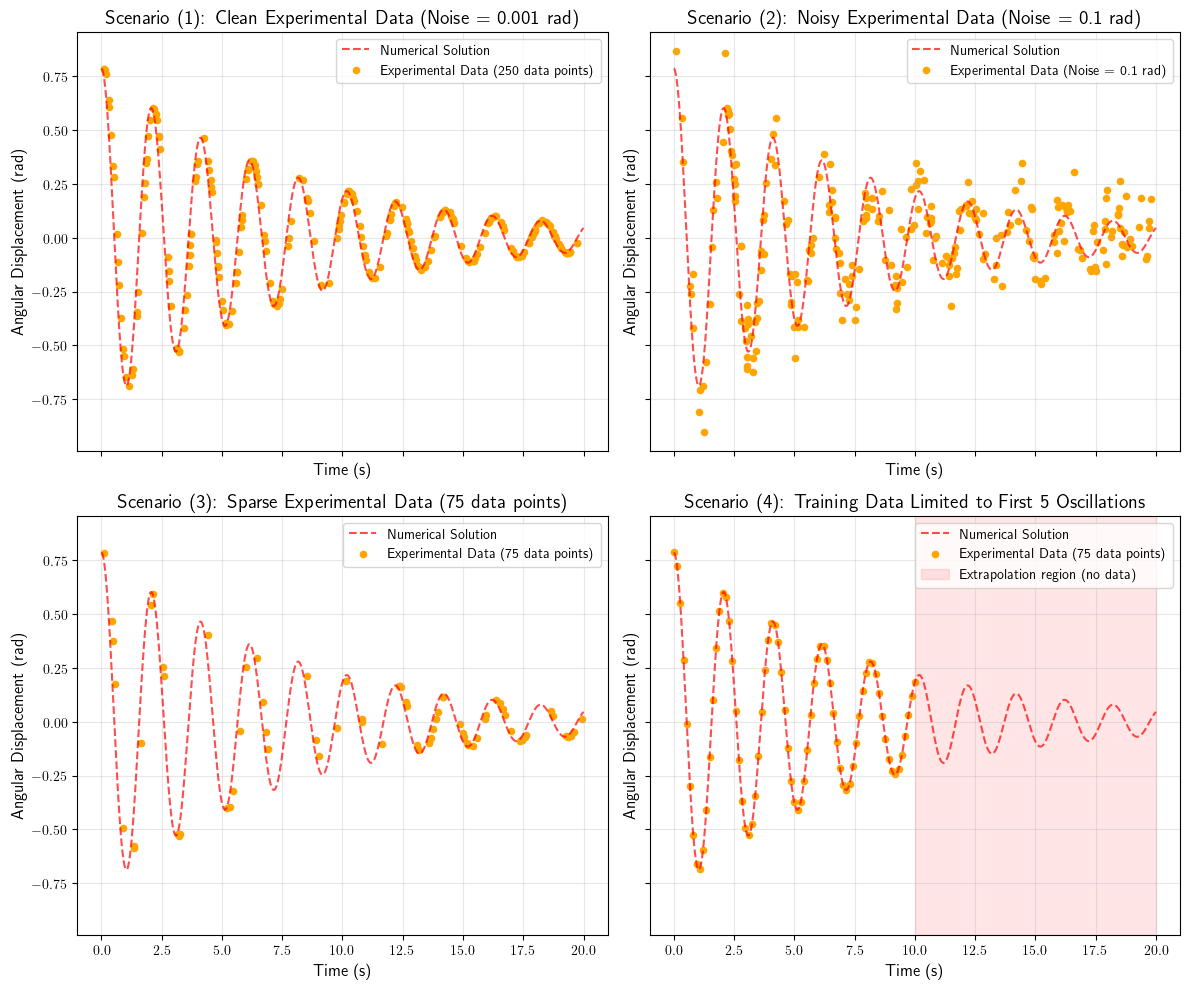

In [6]:
# ----------------------------------------------------------------------------
# Plot all scenarios together for comparison
fig, axes = plt.subplots(
    2,2,
    figsize=(12, 10),
    sharex=True,
    sharey=True)

# Scenario (1): Clean Experimental Data with Low Noise (0.001 rad)
ax1 = axes[0, 0]
ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax1.scatter(
    t_exp_np_clean_data,
    exp_theta_np_clean_data,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_clean_data} data points)')

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax1.set_title(
    "Scenario (1): Clean Experimental Data " 
    + rf"(Noise = {exp_noise_clean_data} rad)",
    fontsize=14)
ax1.legend(
    fontsize=10,
    loc='upper right')
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Scenario (2): Noisy Experimental Data with Higher Noise (0.1 rad)
ax2 = axes[0, 1]
ax2.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax2.scatter(
    t_exp_np_noisy_data,
    exp_theta_np_noisy_data,
    color='orange',
    s=20,
    label=fr'Experimental Data (Noise = {exp_noise_noisy_data} rad)')

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax2.set_title(
    "Scenario (2): Noisy Experimental Data "
    + rf"(Noise = {exp_noise_noisy_data} rad)",
    fontsize=14)
ax2.legend(
    fontsize=10,
    loc='upper right')
ax2.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Scenario (3): Sparse Experimental Data with Only 75 Data Points
ax3 = axes[1, 0]
ax3.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax3.scatter(
    t_exp_np_sparse,
    exp_theta_np_sparse,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_sparse} data points)')

ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax3.set_title(
    "Scenario (3): " 
    f"Sparse Experimental Data ({N_exp_points_sparse} data points)",
    fontsize=14)
ax3.legend(
    fontsize=10,
    loc='upper right')
ax3.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Scenario (4): Extrapolation Test with Data Only in the First Half of the 
# Time Range

ax4 = axes[1, 1]
ax4.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax4.scatter(
    t_exp_np_extrapolate,
    exp_theta_np_extrapolate,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_extrapolate} data points)')

# Shade the extrapolation region
ax4.axvspan(t_data_end, t_end, alpha=0.10, color='red',
            label='Extrapolation region (no data)')

ax4.set_xlabel('Time (s)', fontsize=12)
ax4.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax4.set_title(
    "Scenario (4): Training Data Limited to First 5 Oscillations",
    fontsize=14)
ax4.legend(
    fontsize=10,
    loc='upper right')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "figures/experimental_data_scenarios.png",
    dpi=600,
    bbox_inches='tight')

plt.show()

# Scenario (1): Fourier Feature PINN for Clean Data

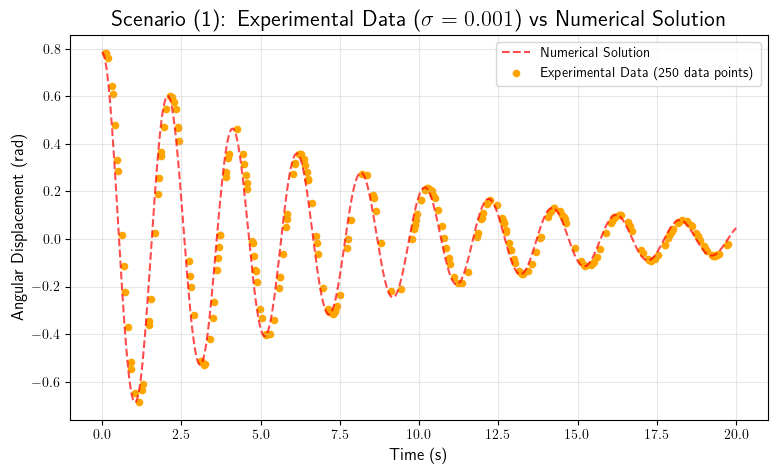

In [7]:
fig, ax = plt.subplots(
    figsize=(9, 5))

ax.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label=r'Numerical Solution',
    alpha=0.7)
ax.scatter(
    t_exp_np_clean_data,
    exp_theta_np_clean_data,
    color='orange',
    s=20,
    label=rf'Experimental Data ({N_exp_points_clean_data} data points)')

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax.set_title(
    rf"Scenario (1): Experimental Data ($\sigma = {exp_noise_clean_data}$) " 
    + "vs Numerical Solution",
    fontsize=16)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [8]:
# ----------------------------------------------------------------------------
# Time normalization
# Time normalization constants
t_min = t_start
t_max = t_end
dt    = t_max - t_min

# Normalize time to [-1, +1]
# Formula: t_norm = 2*(t - t_min)/dt - 1
# t=0 → -1,  t=10 → 0,  t=20 → +1
time_exp_norm_np     = 2 * (t_exp_np_clean_data - t_min) / dt - 1.0

# Convert to PyTorch tensors
time_exp_norm_clean_data     = torch.from_numpy(
    time_exp_norm_np).float().view(-1, 1).to(device)

# Check that the normalized time is in the expected range [-1, +1]
print("time_exp_norm range:") 
print(f"[{time_exp_norm_clean_data.min():.3f}, "
      f"{time_exp_norm_clean_data.max():.3f}]")

print("-"*79)

# ----------------------------------------------------------------------------
# Displacement normalization constants (from synthetic experimental data)
theta_mean = np.mean(exp_theta_np_clean_data)

# Use sample std for unbiased estimate of population std (ddof=1)
theta_std  = np.std(exp_theta_np_clean_data, ddof=1)

# Standardize displacement (zero mean, unit std)
# Formula: theta_norm = (theta - mean) / std
theta_exp_norm_np = (exp_theta_np_clean_data - theta_mean) / theta_std

theta_exp_norm_clean_data = torch.from_numpy(
    theta_exp_norm_np).float().view(-1, 1).to(device)

# Check that the normalized displacement has mean ≈ 0 and std ≈ 1
print("Displacement theta_exp_norm mean:") 
print(f"{theta_exp_norm_clean_data.mean():.4f}")
print("-"*79)
print("Displacement theta_exp_norm std:") 
print(f"{theta_exp_norm_clean_data.std():.4f}")

time_exp_norm range:
[-0.990, 0.974]
-------------------------------------------------------------------------------
Displacement theta_exp_norm mean:
-0.0000
-------------------------------------------------------------------------------
Displacement theta_exp_norm std:
1.0000


In [9]:
# ---------------------------------------------------------------------------
# Frequency bands (rad/s)
# Fourier feature input: sin/cos at pendulum harmonics overcome
# Tanh spectral bias so the network can represent oscillations.
omega_n = np.sqrt(g / L)    # ≈ 3.13 rad/s
omega_freqs = [
    0.5 * omega_n,          # sub-harmonic (decay envelope)
    1.0 * omega_n,          # fundamental oscillation
    1.5 * omega_n,          # nonlinear frequency shift
    2.0 * omega_n,          # 2nd harmonic from sin(θ)
    3.0 * omega_n,          # 3rd harmonic
]

print(f"Natural frequency  ω_n = {omega_n:.3f} rad/s")
print(f"Fourier bands (rad/s): "
      + ", ".join(f"{w:.2f}" for w in omega_freqs))
print(f"Input dimension: 1 + 2×{len(omega_freqs)} = "
      f"{1 + 2*len(omega_freqs)}")

# ---------------------------------------------------------------------------
# Denormalize the predicted theta back to physical units (radians)
def denormalize_theta(
    theta_tensor,
    theta_mean,
    theta_std):
    
    return theta_tensor * theta_std + theta_mean

# ---------------------------------------------------------------------------
# PINN hyperparameters
n_hidden = 64
n_layers = 4
learning_rate = 1e-3
lambda_boundary = 1
lambda_physics = 1
lambda_data = 1

# Create the Fourier Feature PINN
fourier_pinn_clean_data = FourierFeatureNN(
    n_hidden, n_layers, omega_freqs, t_min, t_max).to(device)

# ---------------------------------------------------------------------------
# Compute normalization constants for clean data scenario
theta_mean_clean_data = np.mean(exp_theta_np_clean_data)
theta_std_clean_data  = np.std(exp_theta_np_clean_data, ddof=1)

# ---------------------------------------------------------------------------
# Training points
# Initial condition point: t=0
t_ic = torch.tensor(
    [[0.0]],
    device=device,
    requires_grad=True)

# ---------------------------------------------------------------------------
# Print parameter count
for index, p in enumerate(fourier_pinn_clean_data.parameters(), 1):
    print(f"Layer {index}: {p.numel()} parameters with shape: {p.shape}")

print("-" * 60)
total_params = sum(
    p.numel() for p in fourier_pinn_clean_data.parameters())
print(f"Total parameters: {total_params}")

Natural frequency  ω_n = 3.132 rad/s
Fourier bands (rad/s): 1.57, 3.13, 4.70, 6.26, 9.40
Input dimension: 1 + 2×5 = 11
Layer 1: 704 parameters with shape: torch.Size([64, 11])
Layer 2: 64 parameters with shape: torch.Size([64])
Layer 3: 4096 parameters with shape: torch.Size([64, 64])
Layer 4: 64 parameters with shape: torch.Size([64])
Layer 5: 4096 parameters with shape: torch.Size([64, 64])
Layer 6: 64 parameters with shape: torch.Size([64])
Layer 7: 4096 parameters with shape: torch.Size([64, 64])
Layer 8: 64 parameters with shape: torch.Size([64])
Layer 9: 64 parameters with shape: torch.Size([1, 64])
Layer 10: 1 parameters with shape: torch.Size([1])
------------------------------------------------------------
Total parameters: 13313


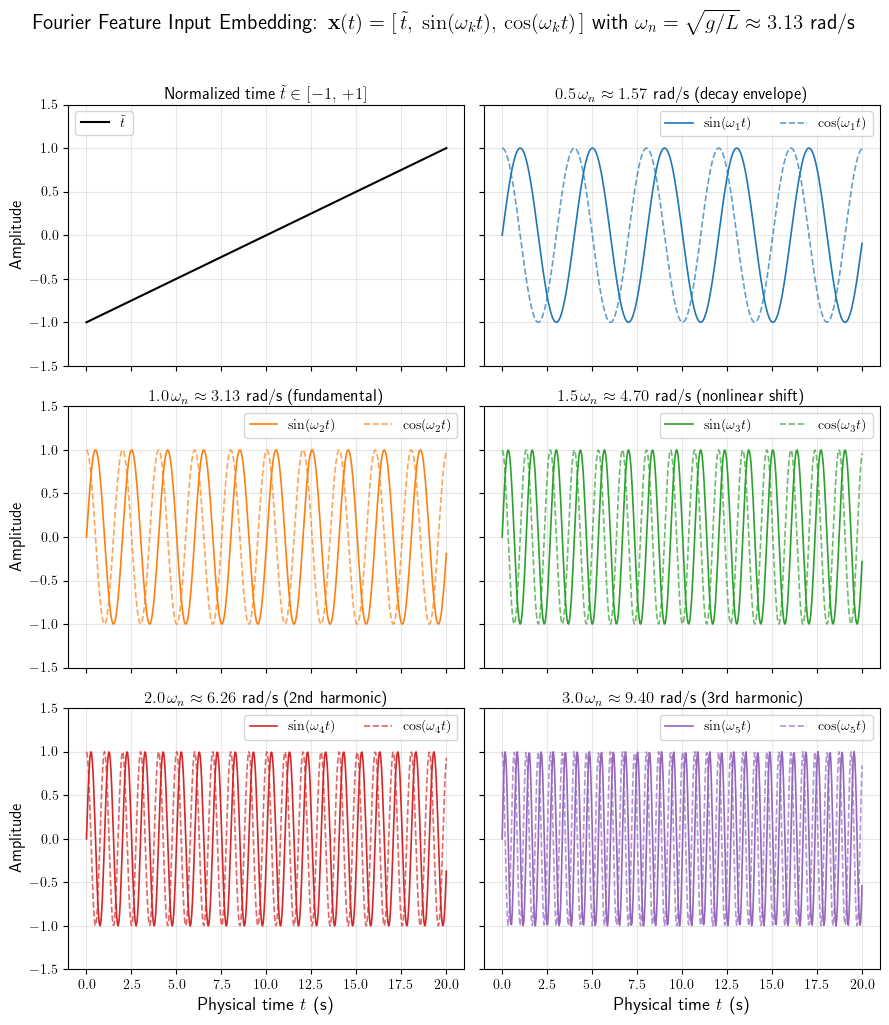

In [10]:
# ---------------------------------------------------------------------------
# Visualise the Fourier feature embedding that the network receives
# as input for each physical time point t.
# Layout: 3 rows × 2 columns
#   (0,0) normalized time       (0,1) 0.5 ω_n  (decay envelope)
#   (1,0) 1.0 ω_n (fundamental) (1,1) 1.5 ω_n  (nonlinear shift)
#   (2,0) 2.0 ω_n (2nd harm.)   (2,1) 3.0 ω_n  (3rd harmonic)
# ---------------------------------------------------------------------------

t_plot = np.linspace(t_start, t_end, 500)

# Normalized time feature: t̃ ∈ [-1, +1]
t_norm_plot = 2.0 * (t_plot - t_start) / (t_end - t_start) - 1.0

# Fourier feature frequencies and titles for each panel
band_titles = [
    rf"$0.5\,\omega_n \approx {0.5*omega_n:.2f}$ rad/s  (decay envelope)",
    rf"$1.0\,\omega_n \approx {1.0*omega_n:.2f}$ rad/s  (fundamental)",
    rf"$1.5\,\omega_n \approx {1.5*omega_n:.2f}$ rad/s  (nonlinear shift)",
    rf"$2.0\,\omega_n \approx {2.0*omega_n:.2f}$ rad/s  (2nd harmonic)",
    rf"$3.0\,\omega_n \approx {3.0*omega_n:.2f}$ rad/s  (3rd harmonic)",
]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

fig, axes = plt.subplots(
    3, 2,
    figsize=(9, 10),
    sharex=True,
    sharey=True)

# ---------------------------------------------------------------------------
# (0, 0): normalized time feature
ax = axes[0, 0]
ax.plot(t_plot, t_norm_plot, color='black', linewidth=1.5)
ax.set_title(
    r"Normalized time $\tilde{t} \in [-1,\,+1]$",
    fontsize=12, pad=4)
ax.set_ylabel("Amplitude", fontsize=12)
ax.set_ylim(-1.5, 1.5)
ax.legend(
    [r"$\tilde{t}$"],
    fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# Remaining 5 panels: sin/cos pairs for each frequency band
# Panel order: (0,1), (1,0), (1,1), (2,0), (2,1)
panel_positions = [(0, 1), (1, 0), (1, 1), (2, 0), (2, 1)]

for k, ((row, col), omega_k, title, color) in enumerate(
        zip(panel_positions, omega_freqs, band_titles, colors)):
    ax = axes[row, col]

    # Fourier features: sin(ω_k · t) and cos(ω_k · t)
    sin_feat = np.sin(omega_k * t_plot)
    cos_feat = np.cos(omega_k * t_plot)

    # Plot sin and cos features with different line styles
    ax.plot(t_plot, sin_feat, color=color, linewidth=1.2,
            label=rf"$\sin(\omega_{{{k+1}}} t)$")
    ax.plot(t_plot, cos_feat, color=color, linewidth=1.2,
            linestyle="dashed", alpha=0.7,
            label=rf"$\cos(\omega_{{{k+1}}} t)$")

    ax.set_title(title, fontsize=12, pad=4)
    if col == 0:
        ax.set_ylabel("Amplitude", fontsize=12)
    ax.set_ylim(-1.5, 1.5)
    ax.legend(fontsize=10, loc="upper right", ncol=2)
    ax.grid(True, alpha=0.3)

# x-axis label only on the bottom row
for col in range(2):
    axes[2, col].set_xlabel("Physical time  $t$  (s)", fontsize=13)

fig.suptitle(
    r"Fourier Feature Input Embedding:  $\mathbf{x}(t) = "
    r"[\,\tilde{t},\; \sin(\omega_k t),\, \cos(\omega_k t)\,]$"
    f"  with  "
    rf"$\omega_n = \sqrt{{g/L}} \approx {omega_n:.2f}$ rad/s",
    fontsize=15, y=1.02)

plt.tight_layout()
plt.savefig(
    "figures/fourier_feature_embedding.png",
    dpi=600,
    bbox_inches="tight")
plt.show()

In [11]:
# NOTE: The FourierFeatureNN handles time normalization internally,
# so we pass *physical* time to pinn() everywhere (no more
# normalize_time_input() calls).

# Curriculum training to progressively expand the time window:
# Curriculum schedule: (t_window_end, epochs, collocation_points)
curriculum = [
    ( 5, 2000,  300),
    (10, 3000,  600),
    (15, 4000,  900),
    (20, 8000, 1200),
]

alpha_causal = 3.0         # causal weight slope per stage
beta_data    = 2.0         # exponential data-weight decay rate

total_loss_history_clean_data   = []
ic_loss_history_clean_data      = []
physics_loss_history_clean_data = []
data_loss_history_clean_data    = []
collocation_points_history_clean_data = []

# Record cumulative epoch count at each stage boundary for plotting
stage_boundaries_clean_data  = []
cumulative_epochs = 0

start_time_training = time.time()

# Loop over curriculum stages
for stage, (t_win, n_epochs, n_coll_points) in enumerate(curriculum, 1):

    # ------------------------------------------------------------------------
    # Stage-specific collocation points
    t_phys = torch.linspace(
        t_start, t_win, n_coll_points, device=device).view(-1, 1)
    t_phys.requires_grad_(True)

    # Actual collocation points used during training
    # Store as NumPy array for plotting the distribution of collocation points
    t_phys_np = t_phys[:, 0].detach().cpu().numpy()
    collocation_points_history_clean_data.append(t_phys_np)
    # ------------------------------------------------------------------------
    # Causal weights for physics loss
    # Upweight late-time ODE residual (α=3)
    causal_weights = (
        1.0 + alpha_causal * (t_phys - t_start) / (t_win - t_start)
    ).detach()

    # ------------------------------------------------------------------------
    # Filter experimental data to current window
    mask = t_exp_np_clean_data <= t_win
    t_exp_stage     = t_exp_np_clean_data[mask]
    theta_exp_stage = exp_theta_np_clean_data[mask]

    # Physical time tensor for experimental data (Fourier network
    # expects physical time, not normalized time)
    time_stage_phys = torch.from_numpy(
        t_exp_stage
    ).float().view(-1, 1).to(device)

    # Normalized displacement targets (still needed for data loss)
    theta_stage_norm = torch.from_numpy(
        (theta_exp_stage - theta_mean_clean_data) / theta_std_clean_data
    ).float().view(-1, 1).to(device)

    # ------------------------------------------------------------------------
    # Time-dependent data weights
    # exponential decay w(t)=exp(-β·t/T) to downweight late-time data 
    # where noise >> signal amplitude.
    data_weights = torch.from_numpy(
        np.exp(-beta_data * t_exp_stage / t_end)
    ).float().view(-1, 1).to(device)

    # ------------------------------------------------------------------------
    # Reinitialize optimizer (network weights carry over)
    optimizer = torch.optim.Adam(
        fourier_pinn_clean_data.parameters(),
        lr=learning_rate)

    print(f"\n{'-'*79}")
    print(f"Stage {stage}: t in [0, {t_win}] s | "
          f"{n_epochs} epochs | {n_coll_points} collocation pts | "
          f"{mask.sum()} data pts")
    print(f"{'-'*79}")

    for i in range(n_epochs):
        optimizer.zero_grad()

        # --------------------------------------------------------------------
        # Part 1: IC Loss
        # Pass physical time t=0 directly (Fourier network normalizes
        # internally)
        theta_ic_norm = fourier_pinn_clean_data(t_ic)
        theta_ic      = denormalize_theta(
            theta_ic_norm,
            theta_mean_clean_data,
            theta_std_clean_data)
        
        dtheta_dt_ic  = torch.autograd.grad(
            theta_ic, t_ic,
            torch.ones_like(theta_ic), create_graph=True)[0]


        loss_theta_ic  = torch.mean((theta_ic - theta0_ground_truth) ** 2)
        loss_dtheta_ic = torch.mean((dtheta_dt_ic - omega0_ground_truth) ** 2)
        total_loss_ic  = loss_theta_ic + loss_dtheta_ic

        # --------------------------------------------------------------------
        # Part 2: Physics Loss (causally weighted)
        # Pass physical collocation times directly
        theta_phys_norm  = fourier_pinn_clean_data(t_phys)
        
        theta_phys       = denormalize_theta(
            theta_phys_norm,
            theta_mean_clean_data,
            theta_std_clean_data)

        dtheta_dt_phys   = torch.autograd.grad(
            theta_phys, t_phys,
            torch.ones_like(theta_phys), create_graph=True)[0]
        d2theta_dt2_phys = torch.autograd.grad(
            dtheta_dt_phys, t_phys,
            torch.ones_like(dtheta_dt_phys), create_graph=True)[0]

        r_physics = (
            d2theta_dt2_phys
            + (b/m) * dtheta_dt_phys
            + (g/L) * torch.sin(theta_phys))

        loss_physics = torch.mean(causal_weights * r_physics ** 2)

        # --------------------------------------------------------------------
        # Part 3: Data Loss (time-weighted Huber)
        # Pass physical experimental times directly
        theta_data_norm = fourier_pinn_clean_data(time_stage_phys)

        # Huber data loss to limit influence of noisy outliers (delta=0.5)
        pointwise_huber = torch.nn.functional.huber_loss(
            theta_data_norm, theta_stage_norm,
            reduction='none', delta=0.5)
        loss_data = torch.mean(data_weights * pointwise_huber)

        # --------------------------------------------------------------------
        # Part 4: Total Loss
        total_loss = (
            lambda_boundary * total_loss_ic
            + lambda_physics * loss_physics
            + lambda_data * loss_data)

        total_loss.backward()
        optimizer.step()

        total_loss_history_clean_data.append(total_loss.item())
        ic_loss_history_clean_data.append(total_loss_ic.item())
        physics_loss_history_clean_data.append(loss_physics.item())
        data_loss_history_clean_data.append(loss_data.item())

    cumulative_epochs += n_epochs
    stage_boundaries_clean_data.append(cumulative_epochs)
    print(f"Stage {stage} final loss: {total_loss_history_clean_data[-1]:.6f}")

end_time_training = time.time()
training_duration = end_time_training - start_time_training

print(f"Training complete. " 
      +f"Final loss: {total_loss_history_clean_data[-1]:.6f}")
print(f"Total training time: {training_duration:.4f} seconds")


-------------------------------------------------------------------------------
Stage 1: t in [0, 5] s | 2000 epochs | 300 collocation pts | 70 data pts
-------------------------------------------------------------------------------
Stage 1 final loss: 0.061814

-------------------------------------------------------------------------------
Stage 2: t in [0, 10] s | 3000 epochs | 600 collocation pts | 124 data pts
-------------------------------------------------------------------------------
Stage 2 final loss: 0.034528

-------------------------------------------------------------------------------
Stage 3: t in [0, 15] s | 4000 epochs | 900 collocation pts | 187 data pts
-------------------------------------------------------------------------------
Stage 3 final loss: 0.024662

-------------------------------------------------------------------------------
Stage 4: t in [0, 20] s | 8000 epochs | 1200 collocation pts | 250 data pts
--------------------------------------------------

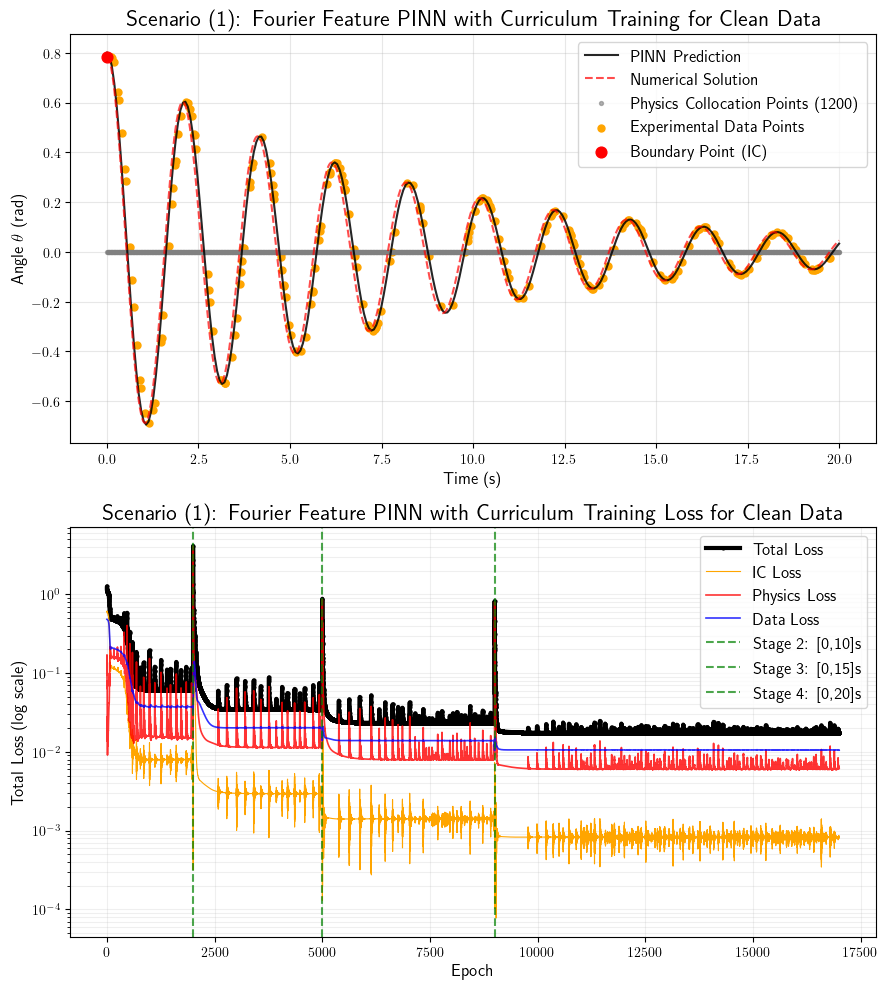

In [12]:
# Evaluate PINN over test points
# Pass physical time directly (FourierFeatureNN normalizes internally)
t_pred_clean_data = torch.linspace(
    t_start, t_end, 300, device=device).view(-1, 1)

with torch.no_grad():
    theta_pred_norm_clean_data = fourier_pinn_clean_data(
        t_pred_clean_data)
    theta_pred_clean_data = denormalize_theta(
        theta_pred_norm_clean_data,
        theta_mean_clean_data,
        theta_std_clean_data)

# Convert to NumPy for plotting
t_pred_np_clean_data    = t_pred_clean_data[:, 0].detach().cpu().numpy()
theta_pred_np_clean_data = theta_pred_clean_data[:, 0].detach().cpu().numpy()


fig, axes = plt.subplots(2, 1, figsize=(9, 10))
fig.subplots_adjust(hspace=0.4)

# ----------------------------------------------------------------------------
# Plot 1: PINN prediction vs numerical solution
ax1 = axes[0]

ax1.plot(
    t_pred_np_clean_data,
    theta_pred_np_clean_data,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7,
    zorder=4)

ax1.scatter(
    collocation_points_history_clean_data[-1],
    np.zeros_like(collocation_points_history_clean_data[-1]),
    color='grey',
    s=8,
    alpha=0.6,
    label=f'Physics Collocation Points ({
        len(collocation_points_history_clean_data[-1])})',
    zorder=3)

ax1.scatter(
    t_exp_np_clean_data,
    exp_theta_np_clean_data,
    color='orange',
    s=25,
    label='Experimental Data Points',
    zorder=2)

ax1.scatter(
    [0], [0.785],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.set_title(
    'Scenario (1): Fourier Feature PINN with Curriculum Training for ' 
    + 'Clean Data',
    fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Training Loss
ax2 = axes[1]
ax2.plot(
    total_loss_history_clean_data,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss")
ax2.plot(
    ic_loss_history_clean_data,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_clean_data,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_clean_data,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines at curriculum stage boundaries
stage_labels = ['[0,5]s', '[0,10]s', '[0,15]s', '[0,20]s']
for idx, ep in enumerate(stage_boundaries_clean_data[:-1]):
    ax2.axvline(
        x=ep,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f'Stage {idx+2}: {stage_labels[idx+1]}')

ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Total Loss (log scale)', fontsize=12)
ax2.set_title(
    'Scenario (1): Fourier Feature PINN with Curriculum Training Loss ' 
    +'for Clean Data',
    fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

# Scenario (2): Test Fourier Hybrid PINN for Noisy Data

The table below summarises how Scenario 2 differs from Scenario 1. The only changes are the noise level and the physics loss weight; every other setting is identical.

| Setting | Scenario 1 (Clean) | Scenario 2 (Noisy) | Comments |
|---------|--------------------:|-------------------:|-------------------|
| Experimental points | 250 | 250 | Same coverage; only noise changes |
| Noise $\sigma$ | 0.001 rad | 0.1 rad | 100× larger noise to stress-test robustness |
| $\lambda_\text{IC}$ | 1 | 1 | IC is exact in both cases |
| $\lambda_\text{phys}$ | 1 | **10** | Physics must dominate to smooth through noisy data |
| $\lambda_\text{data}$ | 1 | 1 | Per-point data weight unchanged; exponential decay + Huber already limit noisy outliers |
| Curriculum schedule | [5, 10, 15, 20] s | [5, 10, 15, 20] s | Same progressive expansion |
| Curriculum epochs | 2 k / 3 k / 4 k / 8 k | 2 k / 3 k / 4 k / 8 k | Same budget per stage |
| Collocation points | 300 / 600 / 900 / 1200 | 300 / 600 / 900 / 1200 | Same physics resolution |
| Causal weight $\alpha$ | 3.0 | 3.0 | Same late-time ODE emphasis |
| Data decay $\beta$ | 2.0 | 2.0 | Same exponential down-weighting of late-time data |
| Huber $\delta$ | 0.5 | 0.5 | Same outlier-clipping threshold |
| Hidden units / layers | 64 / 4 | 64 / 4 | Network capacity unchanged |
| Learning rate | $10^{-3}$ | $10^{-3}$ | Same optimizer settings |

**Key insight:** raising $\lambda_\text{phys}$ from 1 to 10 is the single most important change. With $\sigma = 0.1$ rad the noise amplitude is comparable to the late-time signal ($\lesssim 0.05$ rad after $t \approx 12$ s), so the data loss alone would drive the network toward fitting noise. A 10× physics weight forces the optimizer to prefer ODE-consistent solutions and treat the noisy observations as soft constraints rather than hard targets.

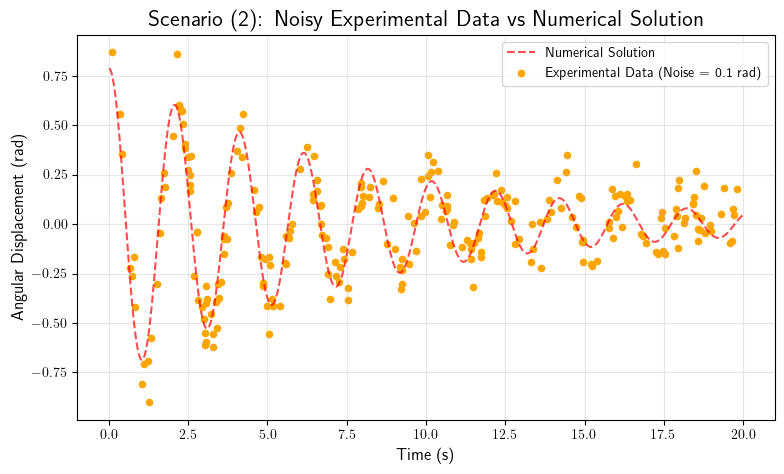

In [13]:
fig, ax = plt.subplots(
    figsize=(9, 5))

ax.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax.scatter(
    t_exp_np_noisy_data,
    exp_theta_np_noisy_data,
    color='orange',
    s=20,
    label=f'Experimental Data (Noise = {exp_noise_noisy_data} rad)')

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax.set_title(
    'Scenario (2): Noisy Experimental Data vs Numerical Solution',
    fontsize=16)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [14]:
# Set random seed for reproducibility
torch.random.manual_seed(42)

# ---------------------------------------------------------------------------
# PINN hyperparameters
n_hidden = 64
n_layers = 4
learning_rate = 1e-3
lambda_boundary = 1
lambda_physics = 10      # physics must dominate noisy data
lambda_data = 1

# Create the Fourier Feature PINN
fourier_pinn_noisy_data = FourierFeatureNN(
    n_hidden, n_layers, omega_freqs, t_min, t_max).to(device)

# ---------------------------------------------------------------------------
# Recompute normalization constants for the noisy Scenario 2 data
theta_mean_noisy_data = np.mean(exp_theta_np_noisy_data)
theta_std_noisy_data  = np.std(exp_theta_np_noisy_data, ddof=1)

# ---------------------------------------------------------------------------
# Training points
# Initial condition point: t=0
t_ic = torch.tensor(
    [[0.0]],
    device=device,
    requires_grad=True)

# ---------------------------------------------------------------------------
# Print parameter count
for index, p in enumerate(fourier_pinn_noisy_data.parameters(), 1):
    print(f"Layer {index}: {p.numel()} parameters with shape: {p.shape}")

print("-" * 60)
total_params = sum(p.numel() for p in fourier_pinn_noisy_data.parameters())
print(f"Total parameters: {total_params}")

Layer 1: 704 parameters with shape: torch.Size([64, 11])
Layer 2: 64 parameters with shape: torch.Size([64])
Layer 3: 4096 parameters with shape: torch.Size([64, 64])
Layer 4: 64 parameters with shape: torch.Size([64])
Layer 5: 4096 parameters with shape: torch.Size([64, 64])
Layer 6: 64 parameters with shape: torch.Size([64])
Layer 7: 4096 parameters with shape: torch.Size([64, 64])
Layer 8: 64 parameters with shape: torch.Size([64])
Layer 9: 64 parameters with shape: torch.Size([1, 64])
Layer 10: 1 parameters with shape: torch.Size([1])
------------------------------------------------------------
Total parameters: 13313


In [15]:
# Curriculum training to progressively expand the time window:
# Curriculum schedule: (t_window_end, epochs, collocation_points)
curriculum = [
    ( 5, 2000,  300),
    (10, 3000,  600),
    (15, 4000,  900),
    (20, 8000, 1200),
]

alpha_causal = 3.0         # causal weight slope per stage
beta_data    = 2.0         # exponential data-weight decay rate

total_loss_history_noisy   = []
ic_loss_history_noisy      = []
physics_loss_history_noisy = []
data_loss_history_noisy    = []
collocation_points_history_noisy = []

# Record cumulative epoch count at each stage boundary for plotting
stage_boundaries_noisy_data  = []
cumulative_epochs = 0

start_time_training = time.time()

# Loop over curriculum stages
for stage, (t_win, n_epochs, n_coll_points) in enumerate(curriculum, 1):

    # ------------------------------------------------------------------------
    # Stage-specific collocation points
    t_phys = torch.linspace(
        t_start, t_win, n_coll_points, device=device).view(-1, 1)
    t_phys.requires_grad_(True)

    # Actual collocation points used during training
    # Store as NumPy array for plotting the distribution of collocation points
    t_phys_np = t_phys[:, 0].detach().cpu().numpy()
    collocation_points_history_noisy.append(t_phys_np)
    # ------------------------------------------------------------------------
    # Causal weights for physics loss
    # Upweight late-time ODE residual (α=3)
    causal_weights = (
        1.0 + alpha_causal * (t_phys - t_start) / (t_win - t_start)
    ).detach()

    # ------------------------------------------------------------------------
    # Filter experimental data to current window
    mask = t_exp_np_noisy_data <= t_win
    t_exp_stage     = t_exp_np_noisy_data[mask]
    theta_exp_stage = exp_theta_np_noisy_data[mask]

    # Physical time tensor for experimental data (Fourier network
    # expects physical time, not normalized time)
    time_stage_phys = torch.from_numpy(
        t_exp_stage
    ).float().view(-1, 1).to(device)

    # Normalized displacement targets (still needed for data loss)
    theta_stage_norm = torch.from_numpy(
        (theta_exp_stage - theta_mean_noisy_data) / theta_std_noisy_data
    ).float().view(-1, 1).to(device)

    # ------------------------------------------------------------------------
    # Time-dependent data weights
    # exponential decay w(t)=exp(-β·t/T) to downweight late-time data 
    # where noise >> signal amplitude.
    data_weights = torch.from_numpy(
        np.exp(-beta_data * t_exp_stage / t_end)
    ).float().view(-1, 1).to(device)

    # ------------------------------------------------------------------------
    # Reinitialize optimizer (network weights carry over)
    optimizer = torch.optim.Adam(
        fourier_pinn_noisy_data.parameters(),
        lr=learning_rate)

    print(f"\n{'-'*79}")
    print(f"Stage {stage}: t in [0, {t_win}] s | "
          f"{n_epochs} epochs | {n_coll_points} collocation pts | "
          f"{mask.sum()} data pts")
    print(f"{'-'*79}")

    for i in range(n_epochs):
        optimizer.zero_grad()

        # --------------------------------------------------------------------
        # Part 1: IC Loss
        # Pass physical time t=0 directly (Fourier network normalizes
        # internally)
        theta_ic_norm = fourier_pinn_noisy_data(t_ic)
        theta_ic      = denormalize_theta(
            theta_ic_norm,
            theta_mean_noisy_data,
            theta_std_noisy_data)
        dtheta_dt_ic  = torch.autograd.grad(
            theta_ic, t_ic,
            torch.ones_like(theta_ic), create_graph=True)[0]

        loss_theta_ic  = torch.mean((theta_ic - theta0_ground_truth) ** 2)
        loss_dtheta_ic = torch.mean((dtheta_dt_ic - omega0_ground_truth) ** 2)
        total_loss_ic  = loss_theta_ic + loss_dtheta_ic

        # --------------------------------------------------------------------
        # Part 2: Physics Loss (causally weighted)
        # Pass physical collocation times directly
        theta_phys_norm  = fourier_pinn_noisy_data(t_phys)
        theta_phys       = denormalize_theta(
            theta_phys_norm,
            theta_mean_noisy_data,
            theta_std_noisy_data)

        dtheta_dt_phys   = torch.autograd.grad(
            theta_phys, t_phys,
            torch.ones_like(theta_phys), create_graph=True)[0]
        d2theta_dt2_phys = torch.autograd.grad(
            dtheta_dt_phys, t_phys,
            torch.ones_like(dtheta_dt_phys), create_graph=True)[0]

        r_physics = (
            d2theta_dt2_phys
            + (b/m) * dtheta_dt_phys
            + (g/L) * torch.sin(theta_phys))

        loss_physics = torch.mean(causal_weights * r_physics ** 2)

        # --------------------------------------------------------------------
        # Part 3: Data Loss (time-weighted Huber)
        # Pass physical experimental times directly
        theta_data_norm = fourier_pinn_noisy_data(time_stage_phys)

        # Huber data loss to limit influence of noisy outliers (delta=0.5)
        pointwise_huber = torch.nn.functional.huber_loss(
            theta_data_norm, theta_stage_norm,
            reduction='none', delta=0.5)
        loss_data = torch.mean(data_weights * pointwise_huber)

        # --------------------------------------------------------------------
        # Part 4: Total Loss
        total_loss = (
            lambda_boundary * total_loss_ic
            + lambda_physics * loss_physics
            + lambda_data * loss_data)

        total_loss.backward()
        optimizer.step()

        total_loss_history_noisy.append(total_loss.item())
        ic_loss_history_noisy.append(total_loss_ic.item())
        physics_loss_history_noisy.append(loss_physics.item())
        data_loss_history_noisy.append(loss_data.item())

    cumulative_epochs += n_epochs
    stage_boundaries_noisy_data.append(cumulative_epochs)
    print(f"Stage {stage} final loss: {total_loss_history_noisy[-1]:.6f}")

end_time_training = time.time()
training_duration = end_time_training - start_time_training

print(f"\nTraining complete. Final loss: {total_loss_history_noisy[-1]:.6f}")
print(f"Total training time: {training_duration:.4f} seconds")


-------------------------------------------------------------------------------
Stage 1: t in [0, 5] s | 2000 epochs | 300 collocation pts | 71 data pts
-------------------------------------------------------------------------------
Stage 1 final loss: 0.095832

-------------------------------------------------------------------------------
Stage 2: t in [0, 10] s | 3000 epochs | 600 collocation pts | 133 data pts
-------------------------------------------------------------------------------
Stage 2 final loss: 0.062574

-------------------------------------------------------------------------------
Stage 3: t in [0, 15] s | 4000 epochs | 900 collocation pts | 195 data pts
-------------------------------------------------------------------------------
Stage 3 final loss: 0.048000

-------------------------------------------------------------------------------
Stage 4: t in [0, 20] s | 8000 epochs | 1200 collocation pts | 250 data pts
--------------------------------------------------

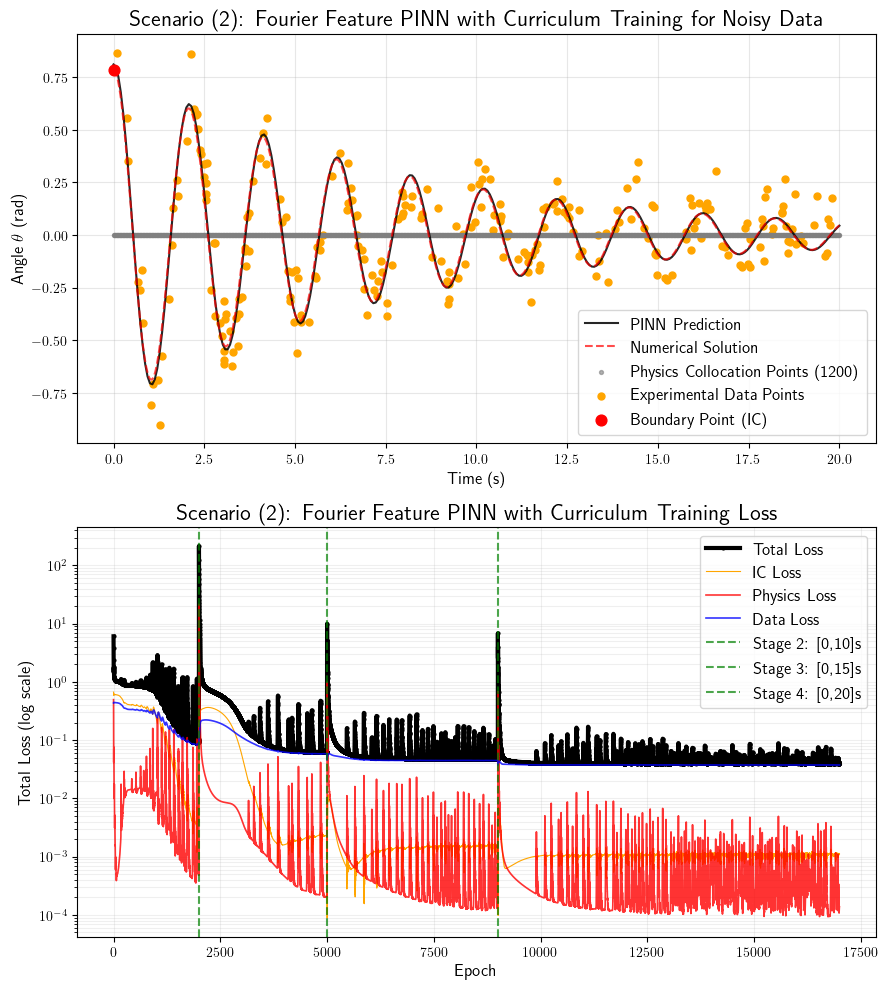

In [16]:
# Evaluate Fourier PINN for noisy dataset over test points
# Pass physical time directly (FourierFeatureNN normalizes internally)
t_pred_noisy = torch.linspace(t_start, t_end, 300, device=device).view(-1, 1)

with torch.no_grad():
    theta_pred_norm_noisy = fourier_pinn_noisy_data(t_pred_noisy)
    theta_pred_noisy      = denormalize_theta(
        theta_pred_norm_noisy,
        theta_mean_noisy_data,
        theta_std_noisy_data)

# Convert to NumPy for plotting
t_pred_np_noisy     = t_pred_noisy[:, 0].detach().cpu().numpy()
theta_pred_np_noisy = theta_pred_noisy[:, 0].detach().cpu().numpy()

# ----------------------------------------------------------------------------
# Plot 1: PINN prediction vs numerical solution

fig, axes = plt.subplots(2, 1, figsize=(9, 10))
ax1 = axes[0]

# Plot the PINN prediction
ax1.plot(
    t_pred_np_noisy,
    theta_pred_np_noisy,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

# Plot the original numerical solution for reference
ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7,
    zorder=4)

# Plot collocation points
ax1.scatter(
    collocation_points_history_noisy[-1],
    np.zeros_like(collocation_points_history_noisy[-1]),
    color='grey',
    s=8,
    alpha=0.6,
    label=f'Physics Collocation Points ({
        len(collocation_points_history_noisy[-1])})',
    zorder=3)

# Plot the experimental data points (with noise)
ax1.scatter(
    t_exp_np_noisy_data,
    exp_theta_np_noisy_data,
    color='orange',
    s=25,
    label='Experimental Data Points',
    zorder=2)

ax1.scatter(
    [0], [0.785],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.set_title(
    "Scenario (2): "
    + "Fourier Feature PINN with Curriculum Training for Noisy Data",
    fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Training Loss
ax2 = axes[1]
ax2.plot(
    total_loss_history_noisy,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss")
ax2.plot(
    ic_loss_history_noisy,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_noisy,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_noisy,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines at curriculum stage boundaries
stage_labels = ['[0,5]s', '[0,10]s', '[0,15]s', '[0,20]s']
for idx, ep in enumerate(stage_boundaries_noisy_data[:-1]):
    ax2.axvline(
        x=ep,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f'Stage {idx+2}: {stage_labels[idx+1]}')

ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Total Loss (log scale)', fontsize=12)
ax2.set_title(
    'Scenario (2): Fourier Feature PINN with Curriculum Training Loss',
    fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

# Scenario (3): Test Hybrid PINN with Sparse Experimental Dataset

In this scenario, we reduce the number of experimental observations from 250 to just 75 while keeping the noise level low (σ = 0.001 rad). This simulates a realistic situation where sensor measurements are expensive, infrequent, or only partially available, but the sensors themselves are accurate.

## Comparison of all three scenarios

| Setting | Scenario 1 (Clean) | Scenario 2 (Noisy) | Scenario 3 (Sparse) |
|---|---|---|---|
| **Data** | - | - | - |
| Experimental points | 250 | 250 | **75** |
| Noise σ | 0.001 rad | **0.1 rad** | 0.001 rad |
| Data window | [0, 20] s | [0, 20] s | [0, 20] s |
| **Loss weights** | - | - | - |
| λ_IC | 1 | 1 | 1 |
| λ_phys | 1 | **10** | 1 |
| λ_data | 1 | 1 | **10** |
| **Curriculum schedule** | - | - | - |
| Stage windows | [5, 10, 15, 20] s | [5, 10, 15, 20] s | [5, 10, 15, 20] s |
| Stage epochs | 2k / 3k / 4k / 8k | 2k / 3k / 4k / 8k | 2k / 3k / 4k / 8k |
| Collocation points | 300 / 600 / 900 / 1200 | 300 / 600 / 900 / 1200 | 300 / 600 / 900 / 1200 |
| **Training strategies** | - | - | - |
| Causal weight α | 3.0 | 3.0 | 3.0 |
| Data decay β | 2.0 | 2.0 | 2.0 |
| Huber δ | 0.5 | 0.5 | 0.5 |
| **Architecture** | - | - | - |
| Hidden units / layers | 64 / 4 | 64 / 4 | 64 / 4 |
| Learning rate | 1e-3 | 1e-3 | 1e-3 |

**Key differences:**

- **Scenario 2 (Noisy):** The only change from Scenario 1 is a 100× increase in noise (σ = 0.1 rad) and raising λ_phys from 1 to 10. At this noise level the noise amplitude is comparable to the late-time signal (≲ 0.05 rad after t ≈ 12 s), so the physics loss must dominate to prevent the network from fitting noise.

- **Scenario 3 (Sparse):** The number of data points is reduced from 250 to 75 with low noise (σ = 0.001 rad). With 70% fewer observations, there are larger temporal gaps where no data exists. The physics loss should fill these gaps via the ODE constraint. Sparse data is trustworthy but scarce, so we up-weight (λ_data = 10) it to compensate for fewer observations. Here the challenge is coverage, not data contamination.

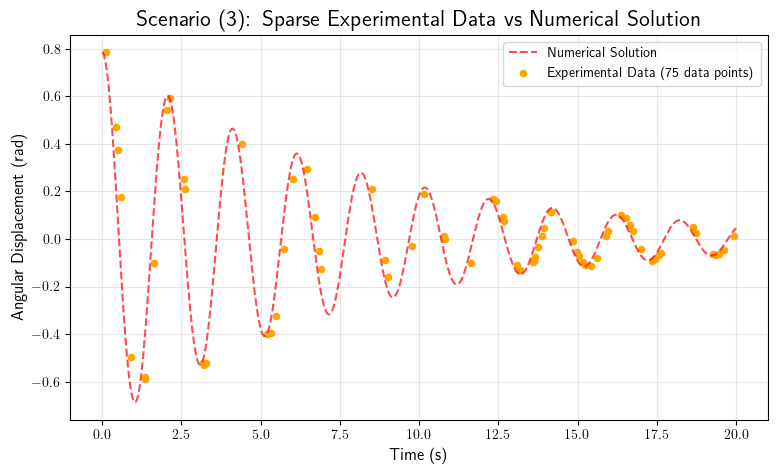

In [17]:
fig, ax = plt.subplots(
    figsize=(9, 5))

ax.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax.scatter(
    t_exp_np_sparse,
    exp_theta_np_sparse,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_sparse} data points)')

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax.set_title(
    'Scenario (3): Sparse Experimental Data vs Numerical Solution',
    fontsize=16)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [18]:
# Set random seed for reproducibility
torch.random.manual_seed(42)

# ---------------------------------------------------------------------------
# PINN hyperparameters
n_hidden = 64
n_layers = 4
learning_rate = 1e-3
lambda_boundary = 1
lambda_physics = 1
lambda_data = 10

# Create the Fourier Feature PINN
fourier_pinn_sparse_data = FourierFeatureNN(
    n_hidden, n_layers, omega_freqs, t_min, t_max).to(device)

# ---------------------------------------------------------------------------
# Recompute normalization constants for the sparse scenario
theta_mean_sparse = np.mean(exp_theta_np_sparse)
theta_std_sparse  = np.std(exp_theta_np_sparse, ddof=1)

# ---------------------------------------------------------------------------
# Training points
# Initial condition point: t=0
t_ic = torch.tensor(
    [[0.0]],
    device=device,
    requires_grad=True)

# ---------------------------------------------------------------------------
# Print parameter count
for index, p in enumerate(fourier_pinn_sparse_data.parameters(), 1):
    print(f"Layer {index}: {p.numel()} parameters with shape: {p.shape}")

print("-" * 60)
total_params = sum(p.numel() for p in fourier_pinn_sparse_data.parameters())
print(f"Total parameters: {total_params}")

Layer 1: 704 parameters with shape: torch.Size([64, 11])
Layer 2: 64 parameters with shape: torch.Size([64])
Layer 3: 4096 parameters with shape: torch.Size([64, 64])
Layer 4: 64 parameters with shape: torch.Size([64])
Layer 5: 4096 parameters with shape: torch.Size([64, 64])
Layer 6: 64 parameters with shape: torch.Size([64])
Layer 7: 4096 parameters with shape: torch.Size([64, 64])
Layer 8: 64 parameters with shape: torch.Size([64])
Layer 9: 64 parameters with shape: torch.Size([1, 64])
Layer 10: 1 parameters with shape: torch.Size([1])
------------------------------------------------------------
Total parameters: 13313


In [19]:
# Curriculum training to progressively expand the time window:
# Curriculum schedule: (t_window_end, epochs, collocation_points)
curriculum = [
    ( 5, 2000,  300),
    (10, 3000,  600),
    (15, 4000,  900),
    (20, 8000, 1200),
]

alpha_causal = 3.0         # causal weight slope per stage
beta_data    = 2.0         # exponential data-weight decay rate

total_loss_history_sparse   = []
ic_loss_history_sparse      = []
physics_loss_history_sparse = []
data_loss_history_sparse    = []
collocation_points_history_sparse = []

# Record cumulative epoch count at each stage boundary for plotting
stage_boundaries_sparse_data  = []
cumulative_epochs = 0

start_time_training = time.time()

# Loop over curriculum stages
for stage, (t_win, n_epochs, n_coll_points) in enumerate(curriculum, 1):

    # ------------------------------------------------------------------------
    # Stage-specific collocation points
    t_phys = torch.linspace(
        t_start, t_win, n_coll_points, device=device).view(-1, 1)
    t_phys.requires_grad_(True)

    # Actual collocation points used during training
    # Store as NumPy array for plotting the distribution of collocation points
    t_phys_np = t_phys[:, 0].detach().cpu().numpy()
    collocation_points_history_sparse.append(t_phys_np)
    # ------------------------------------------------------------------------
    # Causal weights for physics loss
    # Upweight late-time ODE residual (α=3)
    causal_weights = (
        1.0 + alpha_causal * (t_phys - t_start) / (t_win - t_start)
    ).detach()

    # ------------------------------------------------------------------------
    # Filter experimental data to current window
    mask = t_exp_np_sparse <= t_win
    t_exp_stage     = t_exp_np_sparse[mask]
    theta_exp_stage = exp_theta_np_sparse[mask]

    # Physical time tensor for experimental data (Fourier network
    # expects physical time, not normalized time)
    time_stage_phys = torch.from_numpy(
        t_exp_stage
    ).float().view(-1, 1).to(device)

    # Normalized displacement targets (still needed for data loss)
    theta_stage_norm = torch.from_numpy(
        (theta_exp_stage - theta_mean_sparse) / theta_std_sparse
    ).float().view(-1, 1).to(device)

    # ------------------------------------------------------------------------
    # Time-dependent data weights
    # exponential decay w(t)=exp(-β·t/T) to downweight late-time data 
    # where noise >> signal amplitude.
    data_weights = torch.from_numpy(
        np.exp(-beta_data * t_exp_stage / t_end)
    ).float().view(-1, 1).to(device)

    # ------------------------------------------------------------------------
    # Reinitialize optimizer (network weights carry over)
    optimizer = torch.optim.Adam(
        fourier_pinn_sparse_data.parameters(),
        lr=learning_rate)

    print(f"\n{'-'*79}")
    print(f"Stage {stage}: t in [0, {t_win}] s | "
          f"{n_epochs} epochs | {n_coll_points} collocation pts | "
          f"{mask.sum()} data pts")
    print(f"{'-'*79}")

    for i in range(n_epochs):
        optimizer.zero_grad()

        # --------------------------------------------------------------------
        # Part 1: IC Loss
        # Pass physical time t=0 directly (Fourier network normalizes
        # internally)
        theta_ic_norm = fourier_pinn_sparse_data(t_ic)
        theta_ic      = denormalize_theta(
            theta_ic_norm,
            theta_mean_sparse,
            theta_std_sparse)
        dtheta_dt_ic  = torch.autograd.grad(
            theta_ic, t_ic,
            torch.ones_like(theta_ic), create_graph=True)[0]

        loss_theta_ic  = torch.mean((theta_ic - theta0_ground_truth) ** 2)
        loss_dtheta_ic = torch.mean((dtheta_dt_ic - omega0_ground_truth) ** 2)
        total_loss_ic  = loss_theta_ic + loss_dtheta_ic

        # --------------------------------------------------------------------
        # Part 2: Physics Loss (causally weighted)
        # Pass physical collocation times directly
        theta_phys_norm  = fourier_pinn_sparse_data(t_phys)
        theta_phys       = denormalize_theta(
            theta_phys_norm,
            theta_mean_sparse,
            theta_std_sparse)

        dtheta_dt_phys   = torch.autograd.grad(
            theta_phys, t_phys,
            torch.ones_like(theta_phys), create_graph=True)[0]
        d2theta_dt2_phys = torch.autograd.grad(
            dtheta_dt_phys, t_phys,
            torch.ones_like(dtheta_dt_phys), create_graph=True)[0]

        r_physics = (
            d2theta_dt2_phys
            + (b/m) * dtheta_dt_phys
            + (g/L) * torch.sin(theta_phys))

        loss_physics = torch.mean(causal_weights * r_physics ** 2)

        # --------------------------------------------------------------------
        # Part 3: Data Loss (time-weighted Huber)
        # Pass physical experimental times directly
        theta_data_norm = fourier_pinn_sparse_data(time_stage_phys)

        # Huber data loss to limit influence of noisy outliers (delta=0.5)
        pointwise_huber = torch.nn.functional.huber_loss(
            theta_data_norm, theta_stage_norm,
            reduction='none', delta=0.5)
        loss_data = torch.mean(data_weights * pointwise_huber)

        # --------------------------------------------------------------------
        # Part 4: Total Loss
        total_loss = (
            lambda_boundary * total_loss_ic
            + lambda_physics * loss_physics
            + lambda_data * loss_data)

        total_loss.backward()
        optimizer.step()

        total_loss_history_sparse.append(total_loss.item())
        ic_loss_history_sparse.append(total_loss_ic.item())
        physics_loss_history_sparse.append(loss_physics.item())
        data_loss_history_sparse.append(loss_data.item())

    cumulative_epochs += n_epochs
    stage_boundaries_sparse_data.append(cumulative_epochs)
    print(f"Stage {stage} final loss: {total_loss_history_sparse[-1]:.6f}")

end_time_training = time.time()
training_duration = end_time_training - start_time_training

print(f"Training complete. Final loss: {total_loss_history_sparse[-1]:.6f}")
print(f"Total training time: {training_duration:.4f} seconds")


-------------------------------------------------------------------------------
Stage 1: t in [0, 5] s | 2000 epochs | 300 collocation pts | 16 data pts
-------------------------------------------------------------------------------
Stage 1 final loss: 0.266998

-------------------------------------------------------------------------------
Stage 2: t in [0, 10] s | 3000 epochs | 600 collocation pts | 29 data pts
-------------------------------------------------------------------------------
Stage 2 final loss: 0.160898

-------------------------------------------------------------------------------
Stage 3: t in [0, 15] s | 4000 epochs | 900 collocation pts | 51 data pts
-------------------------------------------------------------------------------
Stage 3 final loss: 0.110993

-------------------------------------------------------------------------------
Stage 4: t in [0, 20] s | 8000 epochs | 1200 collocation pts | 75 data pts
-----------------------------------------------------

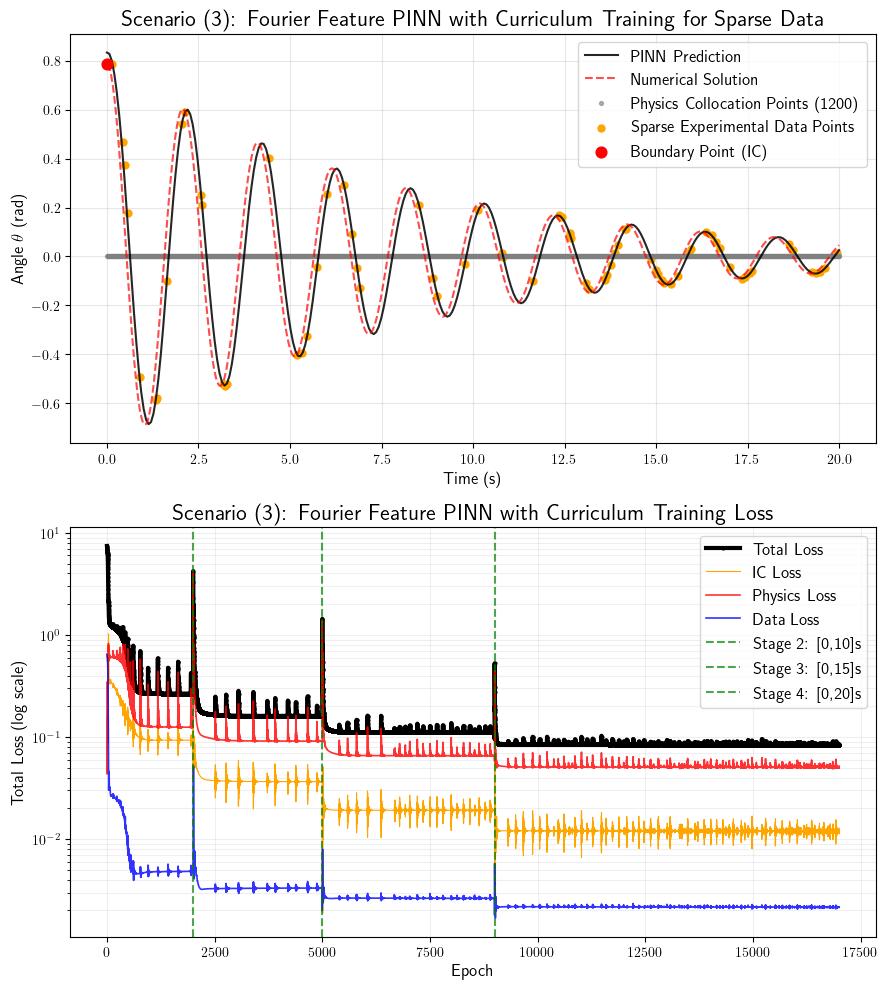

In [20]:
# Evaluate PINN over test points
# Pass physical time directly (FourierFeatureNN normalizes internally)
t_pred_sparse = torch.linspace(
    t_start, t_end, 300, device=device).view(-1, 1)

with torch.no_grad():
    theta_pred_norm_sparse = fourier_pinn_sparse_data(t_pred_sparse)
    theta_pred_sparse      = denormalize_theta(
        theta_pred_norm_sparse,
        theta_mean_sparse,
        theta_std_sparse)

# Convert to NumPy for plotting
t_pred_np_sparse     = t_pred_sparse[:, 0].detach().cpu().numpy()
theta_pred_np_sparse = theta_pred_sparse[:, 0].detach().cpu().numpy()


fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# ----------------------------------------------------------------------------
# Plot 1: PINN prediction vs numerical solution
ax1 = axes[0]

ax1.plot(
    t_pred_np_sparse,
    theta_pred_np_sparse,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7,
    zorder=4)

ax1.scatter(
    collocation_points_history_sparse[-1],
    np.zeros_like(collocation_points_history_sparse[-1]),
    color='grey',
    s=8,
    alpha=0.6,
    label=f'Physics Collocation Points ({
        len(collocation_points_history_sparse[-1])})',
    zorder=3)

ax1.scatter(
    t_exp_np_sparse,
    exp_theta_np_sparse,
    color='orange',
    s=25,
    label='Sparse Experimental Data Points',
    zorder=2)

ax1.scatter(
    [0], [0.785],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.set_title(
    "Scenario (3): "
    + "Fourier Feature PINN with Curriculum Training for Sparse Data",
    fontsize=16)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Training Loss
ax2 = axes[1]
ax2.plot(
    total_loss_history_sparse,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss")
ax2.plot(
    ic_loss_history_sparse,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_sparse,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_sparse,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines at curriculum stage boundaries
stage_labels = ['[0,5]s', '[0,10]s', '[0,15]s', '[0,20]s']
for idx, ep in enumerate(stage_boundaries_sparse_data[:-1]):
    ax2.axvline(
        x=ep,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f'Stage {idx+2}: {stage_labels[idx+1]}')

ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Total Loss (log scale)', fontsize=12)
ax2.set_title(
    'Scenario (3): Fourier Feature PINN with Curriculum Training Loss',
    fontsize=16)
ax2.legend(
    fontsize=12,
    loc='upper right')
ax2.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

# Scenario 4: Test Hybrid PINN for Extrapolation Beyond Training Window

In this scenario, experimental data is limited to the first half of the domain ([0, 10] s) and the PINN must extrapolate the remaining 10 seconds using physics alone. This tests whether the ODE constraint is strong enough to sustain accurate predictions beyond the data horizon.

## Comparison of all four scenarios

| Setting | Sc. 1 (Clean) | Sc. 2 (Noisy) | Sc. 3 (Sparse) | Sc. 4 (Extrapolation) |
|---|---|---|---|---|
| **Data** | - | - | - | - |
| Experimental points | 250 | 250 | 75 | 75 |
| Noise σ | 0.001 rad | **0.1 rad** | 0.001 rad | 0.001 rad |
| Data window | [0, 20] s | [0, 20] s | [0, 20] s | **[0, 10] s** |
| **Loss weights** | - | - | - | - |
| λ_IC | 1 | 1 | 1 | 1 |
| λ_phys | 1 | **10** | 1 | **10** |
| λ_data | 1 | 1 | **10** | 1 |
| **Curriculum schedule** | - | - | - | - |
| Stage windows | [5,10,15,20] s | [5,10,15,20] s | [5,10,15,20] s | [5,10,15,20] s |
| Stage epochs | 2k/3k/4k/8k | 2k/3k/4k/8k | 2k/3k/4k/8k | 2k/3k/4k/8k |
| Collocation pts | 300/600/900/1200 | 300/600/900/1200 | 300/600/900/1200 | 300/600/900/1200 |
| **Training strategies** | - | - | - | - |
| Causal weight α | 3.0 | 3.0 | 3.0 | 3.0 |
| Data decay β | 2.0 | 2.0 | 2.0 | 2.0 |
| Huber δ | 0.5 | 0.5 | 0.5 | 0.5 |
| **Architecture** | - | - | - | - |
| Hidden / layers | 64 / 4 | 64 / 4 | 64 / 4 | 64 / 4 |
| Learning rate | 1e-3 | 1e-3 | 1e-3 | 1e-3 |

**Key differences:**

- **Scenario 2 (Noisy):** 100x increase in noise (σ = 0.1 rad) with λ_phys raised to 10. The noise amplitude rivals the late-time signal, so physics must dominate to prevent fitting noise.

- **Scenario 3 (Sparse):** Data points reduced from 250 to 75 with low noise (σ = 0.001 rad). Larger temporal gaps are filled by the ODE constraint. Loss weights stay at 1 because the data is trustworthy.

- **Scenario 4 (Extrapolation):** Data covers only [0, 10] s (first ~5 oscillations); the PINN must predict [10, 20] s purely from physics. λ_phys is raised to 10 because beyond t = 10 s there are zero data anchors, so the ODE residual is the sole constraint keeping the solution on track. Curriculum stages 3 and 4 ([0, 15] s and [0, 20] s) have collocation points but no data points, making them entirely physics-driven.

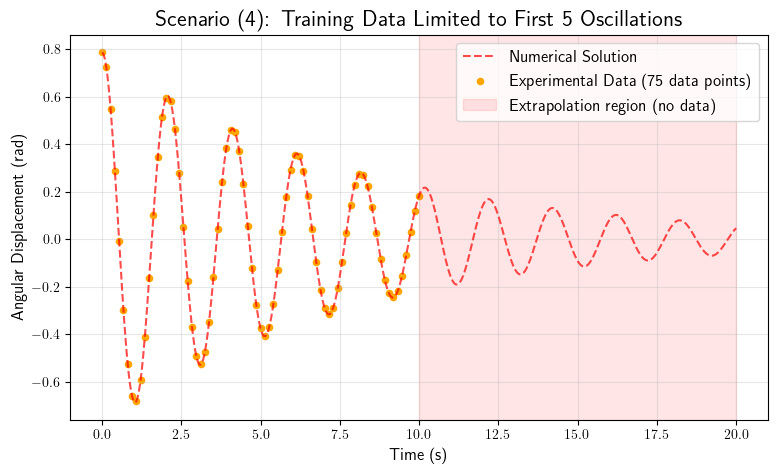

In [21]:
fig, ax = plt.subplots(
    figsize=(9, 5))

ax.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)
ax.scatter(
    t_exp_np_extrapolate,
    exp_theta_np_extrapolate,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_extrapolate} data points)')

# Shade the extrapolation region
ax.axvspan(t_data_end, t_end, alpha=0.10, color='red',
            label='Extrapolation region (no data)')

ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Angular Displacement (rad)', fontsize=12)
ax.set_title(
    'Scenario (4): Training Data Limited to First 5 Oscillations',
    fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.show()

In [22]:
torch.random.manual_seed(42)

# ---------------------------------------------------------------------------
# PINN hyperparameters
n_hidden = 64
n_layers = 4
learning_rate = 1e-3
lambda_boundary = 1
lambda_physics = 10      # physics must dominate during extrapolation
lambda_data = 1

# Create the Fourier Feature PINN
fourier_pinn_extrapolation = FourierFeatureNN(
    n_hidden, n_layers, omega_freqs, t_min, t_max).to(device)

# ---------------------------------------------------------------------------
# Recompute normalization constants for the limited data scenario (Scenario 4)
theta_mean_extrapolate = np.mean(exp_theta_np_extrapolate)
theta_std_extrapolate  = np.std(exp_theta_np_extrapolate, ddof=1)

# ---------------------------------------------------------------------------
# Training points
# Initial condition point: t=0
t_ic = torch.tensor(
    [[0.0]],
    device=device,
    requires_grad=True)

# ---------------------------------------------------------------------------
# Print parameter count
for index, p in enumerate(fourier_pinn_extrapolation.parameters(), 1):
    print(f"Layer {index}: {p.numel()} parameters with shape: {p.shape}")

print("-" * 60)
total_params = sum(p.numel() for p in fourier_pinn_extrapolation.parameters())
print(f"Total parameters: {total_params}")

Layer 1: 704 parameters with shape: torch.Size([64, 11])
Layer 2: 64 parameters with shape: torch.Size([64])
Layer 3: 4096 parameters with shape: torch.Size([64, 64])
Layer 4: 64 parameters with shape: torch.Size([64])
Layer 5: 4096 parameters with shape: torch.Size([64, 64])
Layer 6: 64 parameters with shape: torch.Size([64])
Layer 7: 4096 parameters with shape: torch.Size([64, 64])
Layer 8: 64 parameters with shape: torch.Size([64])
Layer 9: 64 parameters with shape: torch.Size([1, 64])
Layer 10: 1 parameters with shape: torch.Size([1])
------------------------------------------------------------
Total parameters: 13313


In [23]:
# Curriculum training to progressively expand the time window:
# Curriculum schedule: (t_window_end, epochs, collocation_points)
curriculum = [
    ( 5, 2000,  300),
    (10, 3000,  600),
    (15, 4000,  900),
    (20, 8000, 1200),
]

alpha_causal = 3.0         # causal weight slope per stage
beta_data    = 2.0         # exponential data-weight decay rate

total_loss_history_extrapolate   = []
ic_loss_history_extrapolate      = []
physics_loss_history_extrapolate = []
data_loss_history_extrapolate    = []
collocation_points_history_extrapolate = []

# Record cumulative epoch count at each stage boundary for plotting
stage_boundaries_extrapolate  = []
cumulative_epochs = 0

start_time_training = time.time()

# Loop over curriculum stages
for stage, (t_win, n_epochs, n_coll_points) in enumerate(curriculum, 1):

    # ------------------------------------------------------------------------
    # Stage-specific collocation points
    t_phys = torch.linspace(
        t_start, t_win, n_coll_points, device=device).view(-1, 1)
    t_phys.requires_grad_(True)

    # Actual collocation points used during training
    # Store as NumPy array for plotting the distribution of collocation points
    t_phys_np = t_phys[:, 0].detach().cpu().numpy()
    collocation_points_history_extrapolate.append(t_phys_np)

    # ------------------------------------------------------------------------
    # Causal weights for physics loss
    # Upweight late-time ODE residual (α=3)
    causal_weights = (
        1.0 + alpha_causal * (t_phys - t_start) / (t_win - t_start)
    ).detach()

    # ------------------------------------------------------------------------
    # Filter experimental data to current window
    mask = t_exp_np_extrapolate <= t_win
    t_exp_stage     = t_exp_np_extrapolate[mask]
    theta_exp_stage = exp_theta_np_extrapolate[mask]

    # Physical time tensor for experimental data (Fourier network
    # expects physical time, not normalized time)
    time_stage_phys = torch.from_numpy(
        t_exp_stage
    ).float().view(-1, 1).to(device)

    # Normalized displacement targets (still needed for data loss)
    theta_stage_norm = torch.from_numpy(
        (theta_exp_stage - theta_mean_extrapolate) / theta_std_extrapolate
    ).float().view(-1, 1).to(device)

    # ------------------------------------------------------------------------
    # Time-dependent data weights
    # exponential decay w(t)=exp(-β·t/T) to downweight late-time data 
    # where noise >> signal amplitude.
    data_weights = torch.from_numpy(
        np.exp(-beta_data * t_exp_stage / t_end)
    ).float().view(-1, 1).to(device)

    # ------------------------------------------------------------------------
    # Reinitialize optimizer (network weights carry over)
    optimizer = torch.optim.Adam(
        fourier_pinn_extrapolation.parameters(),
        lr=learning_rate)

    print(f"\n{'-'*79}")
    print(f"Stage {stage}: t in [0, {t_win}] s | "
          f"{n_epochs} epochs | {n_coll_points} collocation pts | "
          f"{mask.sum()} data pts")
    print(f"{'-'*79}")

    for i in range(n_epochs):
        optimizer.zero_grad()

        # --------------------------------------------------------------------
        # Part 1: IC Loss
        # Pass physical time t=0 directly (Fourier network normalizes
        # internally)
        theta_ic_norm = fourier_pinn_extrapolation(t_ic)
        theta_ic      = denormalize_theta(
            theta_ic_norm,
            theta_mean_extrapolate,
            theta_std_extrapolate)
        dtheta_dt_ic  = torch.autograd.grad(
            theta_ic, t_ic,
            torch.ones_like(theta_ic), create_graph=True)[0]

        loss_theta_ic  = torch.mean((theta_ic - theta0_ground_truth) ** 2)
        loss_dtheta_ic = torch.mean((dtheta_dt_ic - omega0_ground_truth) ** 2)
        total_loss_ic  = loss_theta_ic + loss_dtheta_ic

        # --------------------------------------------------------------------
        # Part 2: Physics Loss (causally weighted)
        # Pass physical collocation times directly
        theta_phys_norm  = fourier_pinn_extrapolation(t_phys)
        theta_phys       = denormalize_theta(
            theta_phys_norm,
            theta_mean_extrapolate,
            theta_std_extrapolate)

        dtheta_dt_phys   = torch.autograd.grad(
            theta_phys, t_phys,
            torch.ones_like(theta_phys), create_graph=True)[0]
        d2theta_dt2_phys = torch.autograd.grad(
            dtheta_dt_phys, t_phys,
            torch.ones_like(dtheta_dt_phys), create_graph=True)[0]

        r_physics = (
            d2theta_dt2_phys
            + (b/m) * dtheta_dt_phys
            + (g/L) * torch.sin(theta_phys))

        loss_physics = torch.mean(causal_weights * r_physics ** 2)

        # --------------------------------------------------------------------
        # Part 3: Data Loss (time-weighted Huber)
        # Pass physical experimental times directly
        theta_data_norm = fourier_pinn_extrapolation(time_stage_phys)

        # Huber data loss to limit influence of noisy outliers (delta=0.5)
        pointwise_huber = torch.nn.functional.huber_loss(
            theta_data_norm, theta_stage_norm,
            reduction='none', delta=0.5)
        loss_data = torch.mean(data_weights * pointwise_huber)

        # --------------------------------------------------------------------
        # Part 4: Total Loss
        total_loss = (
            lambda_boundary * total_loss_ic
            + lambda_physics * loss_physics
            + lambda_data * loss_data)

        total_loss.backward()
        optimizer.step()

        total_loss_history_extrapolate.append(total_loss.item())
        ic_loss_history_extrapolate.append(total_loss_ic.item())
        physics_loss_history_extrapolate.append(loss_physics.item())
        data_loss_history_extrapolate.append(loss_data.item())

    cumulative_epochs += n_epochs
    stage_boundaries_extrapolate.append(cumulative_epochs)
    print(f"Stage {stage} final loss: " 
          f"{total_loss_history_extrapolate[-1]:.6f}")

end_time_training = time.time()
training_duration = end_time_training - start_time_training

print("Training complete. "
      f"Final loss: {total_loss_history_extrapolate[-1]:.6f}")
print(f"Total training time: {training_duration:.4f} seconds")


-------------------------------------------------------------------------------
Stage 1: t in [0, 5] s | 2000 epochs | 300 collocation pts | 38 data pts
-------------------------------------------------------------------------------
Stage 1 final loss: 0.006070

-------------------------------------------------------------------------------
Stage 2: t in [0, 10] s | 3000 epochs | 600 collocation pts | 75 data pts
-------------------------------------------------------------------------------
Stage 2 final loss: 0.001017

-------------------------------------------------------------------------------
Stage 3: t in [0, 15] s | 4000 epochs | 900 collocation pts | 75 data pts
-------------------------------------------------------------------------------
Stage 3 final loss: 0.025698

-------------------------------------------------------------------------------
Stage 4: t in [0, 20] s | 8000 epochs | 1200 collocation pts | 75 data pts
-----------------------------------------------------

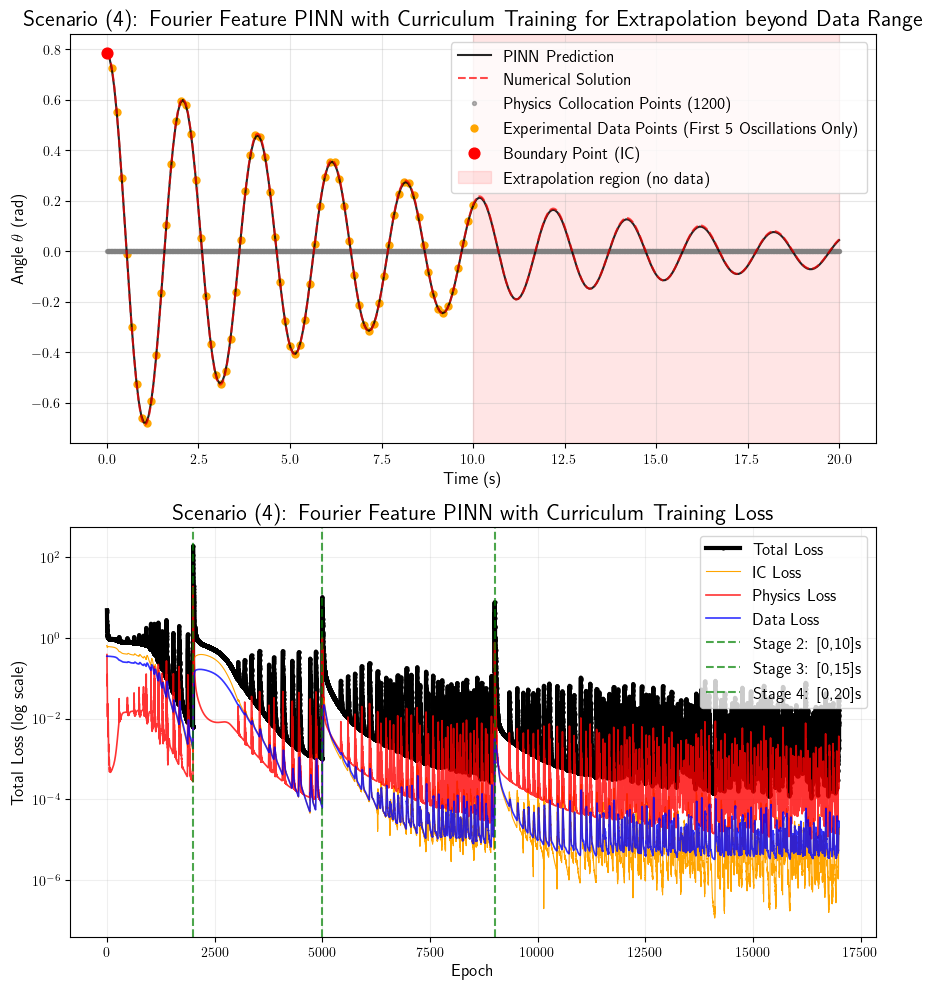

In [24]:
# Evaluate PINN over test points
# Pass physical time directly (FourierFeatureNN normalizes internally)
t_pred_extrapolate = torch.linspace(
    t_start, t_end, 300, device=device).view(-1, 1)

with torch.no_grad():
    theta_pred_norm_extrapolate = fourier_pinn_extrapolation(
        t_pred_extrapolate)
    theta_pred_extrapolate      = denormalize_theta(
        theta_pred_norm_extrapolate,
        theta_mean_extrapolate,
        theta_std_extrapolate)

# Convert to NumPy for plotting
t_pred_np_extrapolate     = (
    t_pred_extrapolate[:, 0].detach().cpu().numpy())
theta_pred_np_extrapolate = (
    theta_pred_extrapolate[:, 0].detach().cpu().numpy())

fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# ----------------------------------------------------------------------------
# Plot 1: PINN prediction vs numerical solution
ax1 = axes[0]

ax1.plot(
    t_pred_np_extrapolate,
    theta_pred_np_extrapolate,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7,
    zorder=4)

ax1.scatter(
    collocation_points_history_extrapolate[-1],
    np.zeros_like(collocation_points_history_extrapolate[-1]),
    color='grey',
    s=8,
    alpha=0.6,
    label=f'Physics Collocation Points ({
        len(collocation_points_history_extrapolate[-1])})',
    zorder=3)

ax1.scatter(
    t_exp_np_extrapolate,
    exp_theta_np_extrapolate,
    color='orange',
    s=25,
    label='Experimental Data Points (First 5 Oscillations Only)',
    zorder=2)

ax1.scatter(
    [0], [0.785],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.set_title(
    "Scenario (4): Fourier Feature PINN with Curriculum Training for "
    + "Extrapolation beyond Data Range",
    fontsize=16)

ax1.grid(True, alpha=0.3)

# Shade the extrapolation region
ax1.axvspan(t_data_end, t_end, alpha=0.10, color='red',
            label='Extrapolation region (no data)')
ax1.legend(fontsize=12)
# ----------------------------------------------------------------------------
# Plot 2: Training Loss
ax2 = axes[1]
ax2.plot(
    total_loss_history_extrapolate,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss")
ax2.plot(
    ic_loss_history_extrapolate ,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_extrapolate,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_extrapolate,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines at curriculum stage boundaries
stage_labels = ['[0,5]s', '[0,10]s', '[0,15]s', '[0,20]s']
for idx, ep in enumerate(stage_boundaries_extrapolate[:-1]):
    ax2.axvline(
        x=ep,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f'Stage {idx+2}: {stage_labels[idx+1]}')

ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Total Loss (log scale)', fontsize=12)
ax2.set_title(
    'Scenario (4): Fourier Feature PINN with Curriculum Training Loss',
    fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)


plt.tight_layout()
plt.show()

# Plot All Scenarios Together

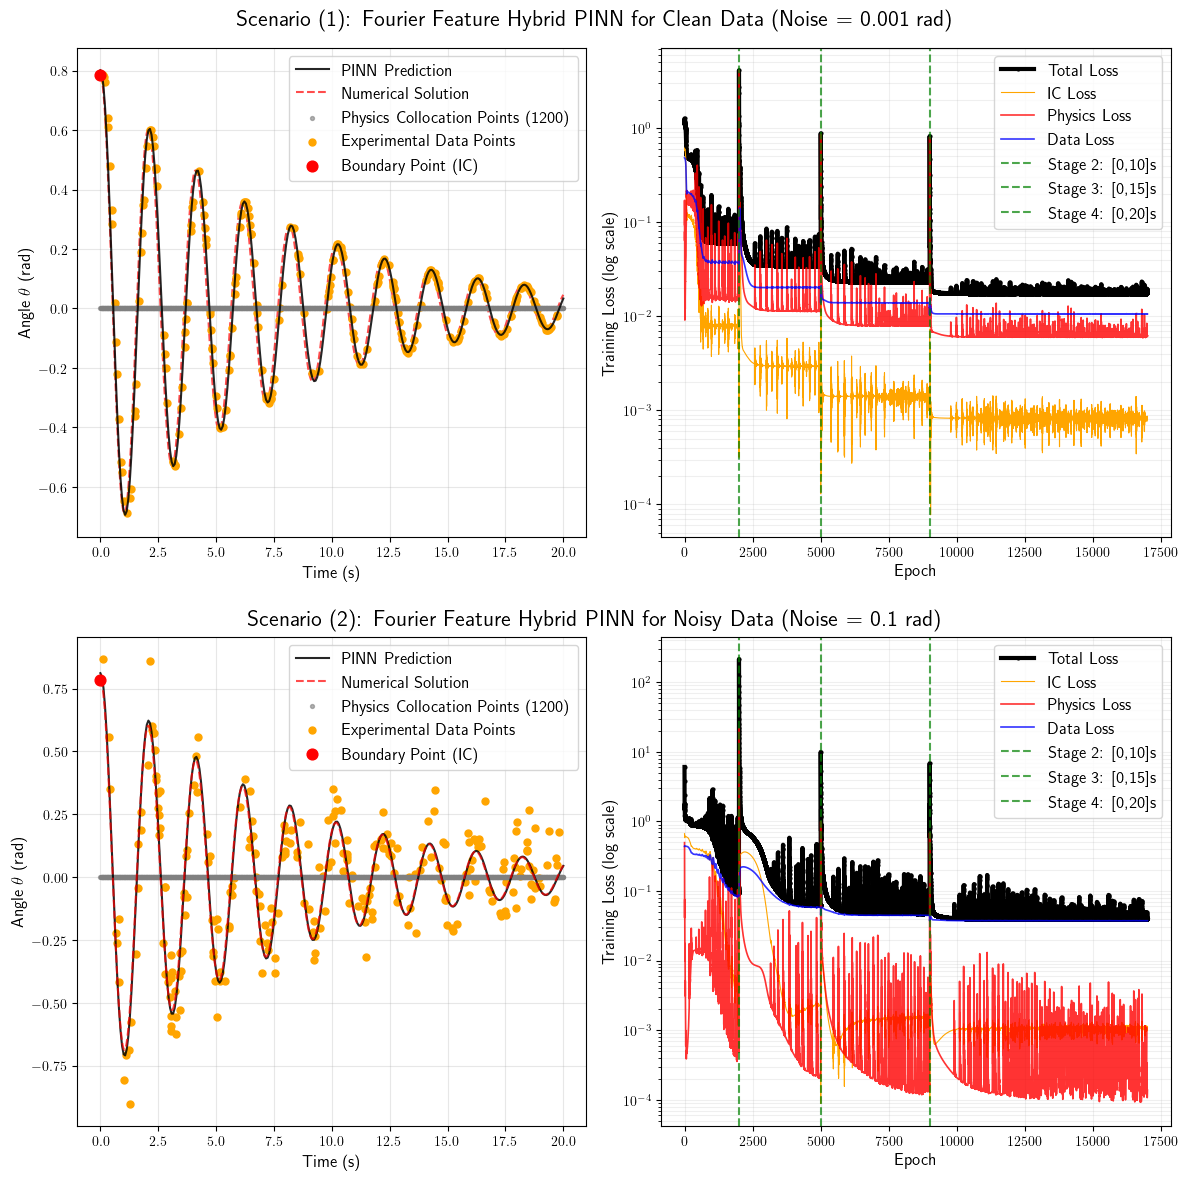

In [25]:
# ----------------------------------------------------------------------------
# Plot all scenarios together for comparison
# Scenario (1) in top row, Scenario (2) in bottom row

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 12))

fig.subplots_adjust(hspace=0.4)

# ----------------------------------------------------------------------------
# Scenario (1): Fourier Feature Hybrid PINN for Clean Data
# ----------------------------------------------------------------------------
# Shared title for Scenario (1), spans ax1 and ax2 (top row)
fig.text(
    0.5, 0.98,
    "Scenario (1): Fourier Feature Hybrid PINN for Clean Data " 
    rf"(Noise = {exp_noise_clean_data} rad)",
    ha='center', va='top', fontsize=16)

ax1 = axes[0, 0]

# Plot the PINN prediction for the clean data scenario
ax1.plot(
    t_pred_np_clean_data,
    theta_pred_np_clean_data,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

# Plot the original numerical solution for reference
ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)

# Plot the physics collocation points
ax1.scatter(
    collocation_points_history_clean_data[-1],
    np.zeros_like(collocation_points_history_clean_data[-1]),
    color='grey',
    s=8,
    alpha=0.6,
    label=f'Physics Collocation Points ({
        len(collocation_points_history_clean_data[-1])})',
    zorder=3)

# Plot the experimental data points for the clean data scenario
ax1.scatter(
    t_exp_np_clean_data,
    exp_theta_np_clean_data,
    color='orange',
    s=25,
    label='Experimental Data Points',
    zorder=2)

# Plot the boundary point (initial condition)
ax1.scatter(
    [0], [0.785],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Scenario (1): Training Loss

ax2 = axes[0, 1]
ax2.plot(
    total_loss_history_clean_data,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss"
    )
ax2.plot(
    ic_loss_history_clean_data,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_clean_data,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_clean_data,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines at curriculum stage boundaries
for idx, ep in enumerate(stage_boundaries_clean_data[:-1]):
    ax2.axvline(
        x=ep,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f'Stage {idx+2}: {stage_labels[idx+1]}')

ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Training Loss (log scale)', fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)

# ----------------------------------------------------------------------------
# Scenario (2): Fourier Feature Hybrid PINN for Noisy Data
# ----------------------------------------------------------------------------
ax3 = axes[1, 0]

# Plot the PINN prediction for the noisy data scenario
ax3.plot(
    t_pred_np_noisy,
    theta_pred_np_noisy,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

# Plot the original numerical solution for reference
ax3.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7,
    zorder=4)

# Plot the physics collocation points
ax3.scatter(
    collocation_points_history_noisy[-1],
    np.zeros_like(collocation_points_history_noisy[-1]),
    color='grey',
    s=8,
    alpha=0.6,
    label=f'Physics Collocation Points ({
        len(collocation_points_history_noisy[-1])})',
    zorder=3)

# Plot the experimental data points for the noisy data scenario
ax3.scatter(
    t_exp_np_noisy_data,
    exp_theta_np_noisy_data,
    color='orange',
    s=25,
    label='Experimental Data Points',
    zorder=2)

# Plot the boundary point (initial condition)
ax3.scatter(
    [0], [0.785],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')
ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax3.legend(fontsize=12)
ax3.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Scenario (2): Training Loss

ax4 = axes[1, 1]
ax4.plot(
    total_loss_history_noisy,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss")
ax4.plot(
    ic_loss_history_noisy,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax4.plot(
    physics_loss_history_noisy,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax4.plot(
    data_loss_history_noisy,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines at curriculum stage boundaries
for idx, ep in enumerate(stage_boundaries_noisy_data[:-1]):
    ax4.axvline(
        x=ep,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f'Stage {idx+2}: {stage_labels[idx+1]}')


# Shared title for Scenario (2), spans ax3 and ax4 (bottom row)
fig.text(
    0.5, 0.48,
    "Scenario (2): Fourier Feature Hybrid PINN for Noisy Data " 
    rf"(Noise = {exp_noise_noisy_data} rad)",
    ha='center', va='top', fontsize=16)

ax4.set_yscale('log')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Training Loss (log scale)', fontsize=12)
ax4.legend(fontsize=12)
ax4.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=4.0)

plt.savefig(
    "figures/fourier_hybrid_pinn_scenario_1_2.png",
    dpi=600,
    bbox_inches='tight')
plt.show()

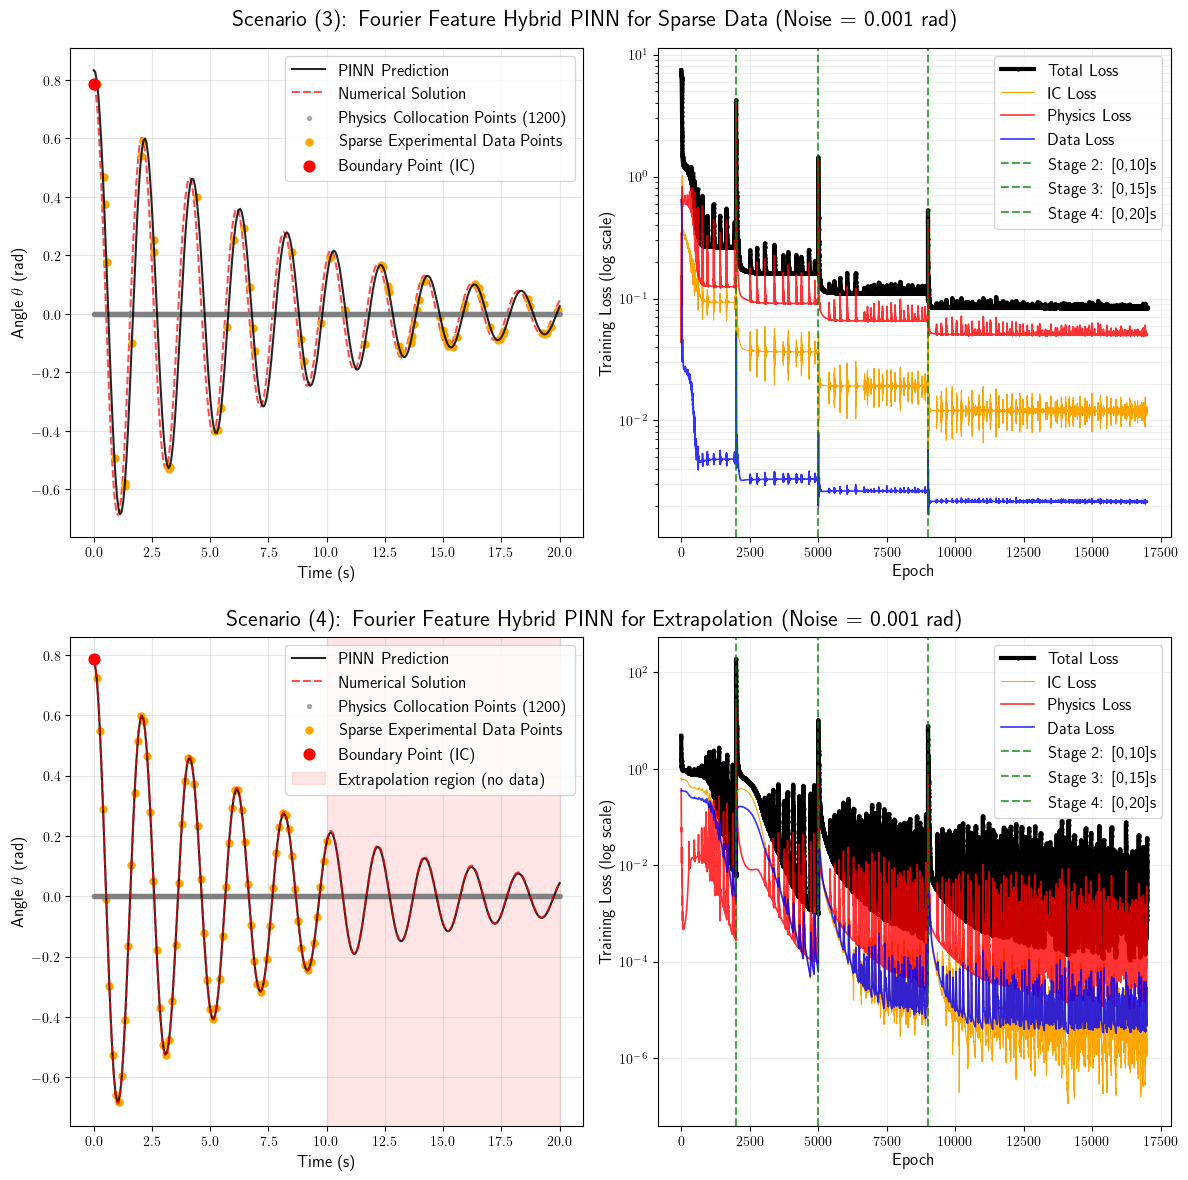

In [26]:
# ----------------------------------------------------------------------------
# Plot all scenarios together for comparison
# Scenario (3) in top row, Scenario (4) in bottom row

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 12))

fig.subplots_adjust(hspace=0.4)

# ----------------------------------------------------------------------------
# Scenario (3): Fourier Feature Hybrid PINN for Sparse Data
# ----------------------------------------------------------------------------

# Shared title for Scenario (3), spans ax1 and ax2 (top row)
fig.text(
    0.5, 0.98,
    "Scenario (3): Fourier Feature Hybrid PINN for Sparse Data " 
    rf"(Noise = {exp_noise_sparse} rad)",
    ha='center', va='top', fontsize=16)

ax1 = axes[0, 0]

# Plot the PINN prediction for the sparse data scenario
ax1.plot(
    t_pred_np_sparse,
    theta_pred_np_sparse,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

# Plot the original numerical solution for reference
ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7)

# Plot the physics collocation points
ax1.scatter(
    collocation_points_history_sparse[-1],
    np.zeros_like(collocation_points_history_sparse[-1]),
    color='grey',
    s=8,
    alpha=0.6,
    label=f'Physics Collocation Points ({
        len(collocation_points_history_sparse[-1])})',
    zorder=3)

# Plot the experimental data points for the sparse data scenario
ax1.scatter(
    t_exp_np_sparse,
    exp_theta_np_sparse,
    color='orange',
    s=25,
    label='Sparse Experimental Data Points',
    zorder=2)

# Plot the boundary point (initial condition)
ax1.scatter(
    [0], [0.785],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Scenario (3): Training Loss
ax2 = axes[0, 1]

ax2.plot(
    total_loss_history_sparse,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss"
    )
ax2.plot(
    ic_loss_history_sparse,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax2.plot(
    physics_loss_history_sparse,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax2.plot(
    data_loss_history_sparse,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines at curriculum stage boundaries
stage_labels = ['[0,5]s', '[0,10]s', '[0,15]s', '[0,20]s']
for idx, ep in enumerate(stage_boundaries_sparse_data[:-1]):
    ax2.axvline(
        x=ep,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f'Stage {idx+2}: {stage_labels[idx+1]}')

ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Training Loss (log scale)', fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)

# ----------------------------------------------------------------------------
# Scenario (4): Fourier Feature Hybrid PINN for Extrapolation
# ----------------------------------------------------------------------------

ax3 = axes[1, 0]

# Plot the PINN prediction for the extrapolation scenario
ax3.plot(
    t_pred_np_extrapolate,
    theta_pred_np_extrapolate,
    color='black',
    label='PINN Prediction',
    alpha=0.85,
    zorder=4)

# Plot the original numerical solution for reference
ax3.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    label='Numerical Solution',
    alpha=0.7,
    zorder=4)

# Plot the physics collocation points
ax3.scatter(
    collocation_points_history_extrapolate[-1],
    np.zeros_like(collocation_points_history_extrapolate[-1]),
    color='grey',
    s=8,
    alpha=0.6,
    label=f'Physics Collocation Points ({
        len(collocation_points_history_extrapolate[-1])})',
    zorder=3)

# Plot the experimental data points for the extrapolation scenario
ax3.scatter(
    t_exp_np_extrapolate,
    exp_theta_np_extrapolate,
    color='orange',
    s=25,
    label='Sparse Experimental Data Points',
    zorder=2)

ax3.scatter(
    [0], [0.785],
    color='red', s=60,
    zorder=5,
    label='Boundary Point (IC)')

# Shade the extrapolation region
ax3.axvspan(t_data_end, t_end, alpha=0.10, color='red',
            label='Extrapolation region (no data)')

ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel(r'Angle $\theta$ (rad)', fontsize=12)
ax3.legend(fontsize=12)
ax3.grid(True, alpha=0.3)

# ----------------------------------------------------------------------------
# Scenario (4): Training Loss

ax4 = axes[1, 1]

ax4.plot(
    total_loss_history_extrapolate,
    marker='o',
    markersize=2,
    color='black',
    linewidth=3,
    label="Total Loss")
ax4.plot(
    ic_loss_history_extrapolate,
    color='orange',
    linewidth=0.8,
    label="IC Loss")
ax4.plot(
    physics_loss_history_extrapolate,
    color='red',
    linewidth=1.2,
    alpha=0.8,
    label="Physics Loss")
ax4.plot(
    data_loss_history_extrapolate,
    color='blue',
    linewidth=1.2,
    alpha=0.8,
    label="Data Loss")

# Add vertical lines at curriculum stage boundaries
for idx, ep in enumerate(stage_boundaries_extrapolate[:-1]):
    ax4.axvline(
        x=ep,
        color='green',
        linestyle='--',
        alpha=0.7,
        label=f'Stage {idx+2}: {stage_labels[idx+1]}')

# Shared title for Scenario (4), spans ax3 and ax4 (bottom row)
fig.text(
    0.5, 0.48,
    "Scenario (4): Fourier Feature Hybrid PINN for Extrapolation " 
    rf"(Noise = {exp_noise_extrapolate} rad)",
    ha='center', va='top', fontsize=16)

ax4.set_yscale('log')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Training Loss (log scale)', fontsize=12)
ax4.legend(fontsize=12)
ax4.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout(rect=[0, 0, 1, 0.96], h_pad=4.0)

plt.savefig(
    "figures/fourier_hybrid_pinn_scenario_3_4.png",
    dpi=600,
    bbox_inches='tight')
plt.show()

# Compare Extrapolation with Pure ML Model

This model uses the same architecture size as the PINN (64 hidden, 4 layers) but is trained purely on MSE between predicted and observed displacement. It receives normalized time as input and outputs normalized theta.

In [27]:
# ---------------------------------------------------------------------------
# Pure ML MLP without physics loss and IC loss, data-only
# ---------------------------------------------------------------------------

torch.random.manual_seed(42)

class PureMLPModel(nn.Module):
    """
    Plain MLP with Tanh activations without Fourier features and physics.
    Designed to test pure data fitting and extrapolation capability.
    """

    def __init__(self, n_hidden, n_layers):
        super().__init__()

        activation = nn.Tanh
        
        self.fcs = nn.Sequential(nn.Linear(1, n_hidden), activation())
        
        self.fch = nn.Sequential(*[
            nn.Sequential(nn.Linear(n_hidden, n_hidden), activation())
            for _ in range(n_layers - 1)])
        
        self.fce = nn.Linear(n_hidden, 1)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

# ---------------------------------------------------------------------------
# Prepare training data (scenario 4: 75 points in [0, 10] s)
# Normalize time to [-1, +1] over the FULL domain [0, 20] s

t_exp_np = t_exp_np_extrapolate
theta_exp_np = exp_theta_np_extrapolate

t_exp_norm_ml = 2.0 * (t_exp_np - t_min) / dt - 1.0
t_train = torch.from_numpy(t_exp_norm_ml).float().view(-1, 1).to(device)
y_train = torch.from_numpy(
    (theta_exp_np - theta_mean_extrapolate) / theta_std_extrapolate
).float().view(-1, 1).to(device)

# ---------------------------------------------------------------------------
# Create model & optimizer
pure_mlp = PureMLPModel(
    n_hidden=64,
    n_layers=4).to(device)

mlp_optimizer = torch.optim.Adam(pure_mlp.parameters(), lr=1e-3)

mlp_scheduler = torch.optim.lr_scheduler.StepLR(
    mlp_optimizer, step_size=5000, gamma=0.5)

mlp_epochs = 20000
mlp_loss_history = []

# ---------------------------------------------------------------------------
# Training loop: pure data MSE
start_ml = time.time()

for ep in range(mlp_epochs):
    mlp_optimizer.zero_grad()
    y_pred = pure_mlp(t_train)
    loss = torch.mean((y_pred - y_train) ** 2)
    loss.backward()
    mlp_optimizer.step()
    mlp_scheduler.step()
    mlp_loss_history.append(loss.item())

ml_duration = time.time() - start_ml
print(f"Pure MLP training complete. Final loss: {mlp_loss_history[-1]:.6f}")
print(f"Training time: {ml_duration:.2f} s")

Pure MLP training complete. Final loss: 0.000089
Training time: 102.82 s


In [28]:
# ---------------------------------------------------------------------------
# Evaluate over the FULL domain [0, 20] s
t_eval_np = np.linspace(t_start, t_end, 300)
t_eval_norm = 2.0 * (t_eval_np - t_min) / dt - 1.0
t_eval_tensor = torch.from_numpy(
    t_eval_norm).float().view(-1, 1).to(device)

# ---------------------------------------------------------------------------
# Get the pure MLP prediction (denormalize to physical theta)
with torch.no_grad():
    y_eval_norm = pure_mlp(t_eval_tensor)
    y_eval = (y_eval_norm.cpu().numpy().flatten() 
        * theta_std_extrapolate + theta_mean_extrapolate)

# ---------------------------------------------------------------------------
# Also get the PINN prediction for side-by-side comparison
t_eval_phys = torch.from_numpy(t_eval_np).float().view(-1, 1).to(device)
with torch.no_grad():
    pinn_pred_norm = fourier_pinn_extrapolation(t_eval_phys)
    pinn_pred = denormalize_theta(
        pinn_pred_norm,
        theta_mean_extrapolate,
        theta_std_extrapolate).cpu().numpy().flatten()


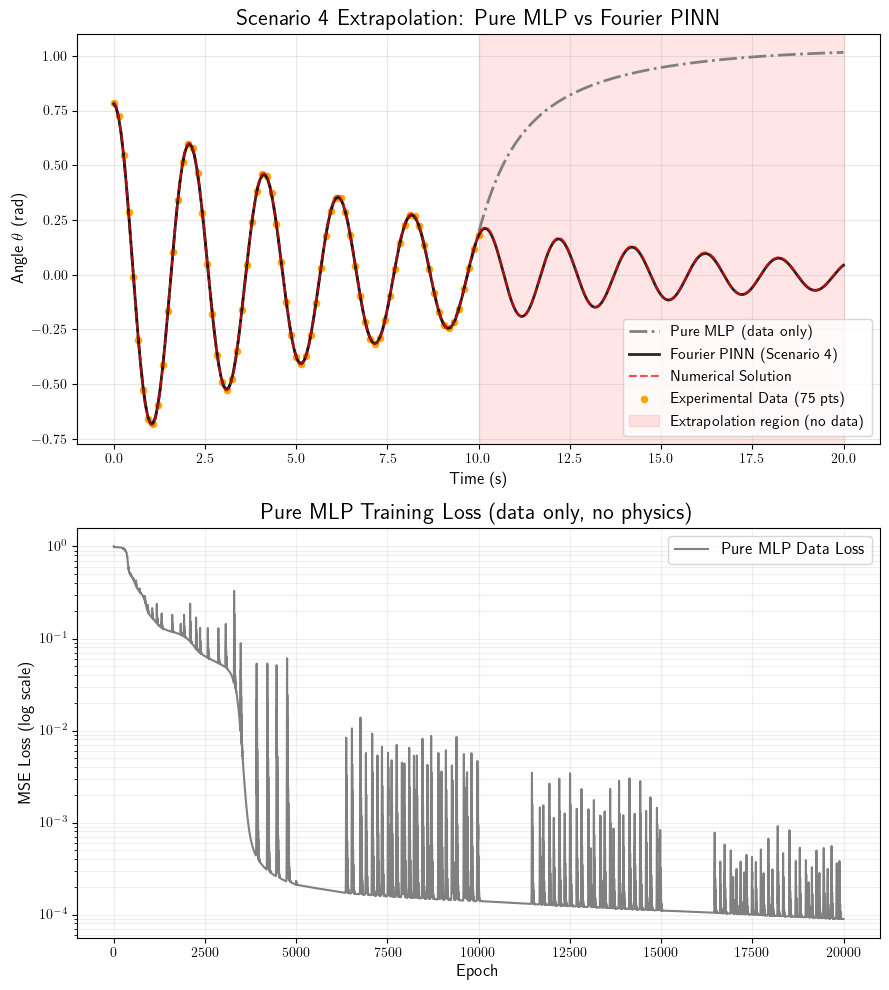

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(9, 10))

# ---------------------------------------------------------------------------
# Pure ML predictions 
ax1 = axes[0]
ax1.plot(
    t_eval_np,
    y_eval,
    color='grey',
    linewidth=2,
    linestyle='dashdot',
    label='Pure MLP (data only)',
    zorder=4)

# PINN prediction
ax1.plot(
    t_eval_np,
    pinn_pred,
    color='black',
    linewidth=2,
    alpha=0.85,
    label='Fourier PINN (Scenario 4)', zorder=4)

# True numerical solution for reference
ax1.plot(
    t_range_ode_ground_truth,
    theta_ground_truth,
    color='red',
    linestyle='dashed',
    alpha=0.7,
    linewidth=1.5,
    label='Numerical Solution',
    zorder=4)

# Experimental data points
ax1.scatter(
    t_exp_np,
    theta_exp_np,
    color='orange',
    s=20,
    label=f'Experimental Data ({N_exp_points_extrapolate} pts)')

# Extrapolation region shading
ax1.axvspan(
    t_data_end,
    t_end,
    alpha=0.10,
    color='red',
    label='Extrapolation region (no data)')
ax1.set_xlabel(
    'Time (s)',
    fontsize=12)
ax1.set_ylabel(
    r'Angle $\theta$ (rad)',
    fontsize=12)
ax1.set_title(
    'Scenario 4 Extrapolation: Pure MLP vs Fourier PINN',
    fontsize=16)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ---------------------------------------------------------------------------
# Bottom: training loss
ax2 = axes[1]
ax2.plot(
    mlp_loss_history,
    color='grey',
    linewidth=1.5,
    label='Pure MLP Data Loss')
ax2.set_yscale('log')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MSE Loss (log scale)', fontsize=12)
ax2.set_title('Pure MLP Training Loss (data only, no physics)', fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', linestyle='-', alpha=0.2)

plt.tight_layout()

plt.savefig(
    "figures/pure_mlp_extrapolation.png",
    dpi=600,
    bbox_inches='tight')

plt.show()

# References

1. Raissi, Maziar, Paris Perdikaris, and George E. Karniadakis. "Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations." Journal of Computational physics 378 (2019): 686-707. [10.1016/j.jcp.2018.10.045](https://www.sciencedirect.com/science/article/pii/S0021999118307125?via%3Dihub)

2. Wang, Sifan, Shyam Sankaran, Hanwen Wang, and Paris Perdikaris. "An expert's guide to training physics-informed neural networks." arXiv preprint arXiv:2308.08468 (2023). [https://doi.org/10.48550/arXiv.2308.08468](https://arxiv.org/abs/2308.08468)

3. Francis Fernandes (2026). [Mastering Dynamics PINNs](https://topmate.io/pinnsformechanicalengineers).

4. Dao, Duc Long. "Experimental evaluation of damping models for a nonlinear pendulum system." Physics Education 58, no. 5 (2023): 055003. [10.1088/1361-6552/ace1ca](https://iopscience.iop.org/article/10.1088/1361-6552/ace1ca/pdf)